# EDA Notebook: Statesbomb Events data, 

# Preprocessing: Reusable EDA function for all dataframes

In [2]:
pip install "polars[all]"

Note: you may need to restart the kernel to use updated packages.Collecting polars[all]
  Using cached polars-1.38.1-py3-none-any.whl.metadata (10 kB)
  Using cached polars_runtime_32-1.38.1-cp310-abi3-win_amd64.whl.metadata (1.5 kB)
     ---------------------------------------- 0.0/90.6 kB ? eta -:--:--
     ---- ----------------------------------- 10.2/90.6 kB ? eta -:--:--
     ---- ----------------------------------- 10.2/90.6 kB ? eta -:--:--
     ------------------------- ------------ 61.4/90.6 kB 544.7 kB/s eta 0:00:01
     -------------------------------------- 90.6/90.6 kB 642.8 kB/s eta 0:00:00
  Using cached importlib_metadata-8.7.1-py3-none-any.whl.metadata (4.7 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
     ---------------------------------------- 0.0/46.7 kB ? eta -:--:--
     ---------------------------------------- 46.7/46.7 kB 1.2 MB/s eta 0:00:00
  Using cached zipp-3.23.0-py3-none-any.whl.metadata (3.6 kB)
Using cached polars_runt


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import polars as pl
import matplotlib.pyplot as plt

def eda_summary(
    df: pl.DataFrame,
    name: str,
    *,
    key_cols: list[str] | None = None,
    numeric_cols: list[str] | None = None,
    categorical_cols: list[str] | None = None,
    boolean_cols: list[str] | None = None,
    sample_n: int = 200_000,
    top_k: int = 15
) -> dict:
    """
    Reusable EDA summary for a Polars DataFrame.

    Returns a dict of Polars DataFrames and other objects you can display in cells.
    Order aligns to the 7-step checklist:
      3) integrity checks
      4) dtypes + ranges
      5) missingness
      6) descriptive stats
      7) initial visuals (basic hist + top categories)

    Notes:
    - For very large dfs, uses sampling for distribution plots.
    - Avoids expensive full-data operations (no global sorting).
    """

    out = {}
    n_rows, n_cols = df.shape

    print(f"\n{'='*90}\nEDA SUMMARY — {name}\nRows: {n_rows:,} | Columns: {n_cols:,}\n{'='*90}")

    # -----------------------------
    # 3) Data integrity checks
    # -----------------------------
    # Basic: duplicates on key cols (if provided), nulls in key cols
    if key_cols is not None:
        key_cols_present = [c for c in key_cols if c in df.columns]
        if len(key_cols_present) > 0:
            integrity = df.select([
                pl.lit(n_rows).alias("n_rows"),
                *[pl.col(c).null_count().alias(f"null_{c}") for c in key_cols_present],
            ])
            # duplicate count on keys (can be heavy if key_cols are many; keep small)
            if len(key_cols_present) <= 4:
                dup_cnt = (
                    df.select(key_cols_present)
                      .is_duplicated()
                      .sum()
                )
                integrity = integrity.with_columns(pl.lit(int(dup_cnt)).alias("duplicate_rows_on_keys"))
            out["integrity"] = integrity
            print("\n[3] Integrity checks:")
            display(integrity)
        else:
            print("\n[3] Integrity checks: key_cols provided but none exist in df.")
    else:
        print("\n[3] Integrity checks: skipped (no key_cols provided).")

    # -----------------------------
    # 4) Numeric ranges + quantiles
    # -----------------------------
    schema = df.schema

#     # Determine numeric cols if not provided
#     if numeric_cols is None:
#         numeric_cols = [c for c, dt in schema.items() if dt.is_numeric()]

    if numeric_cols:
#     if len(numeric_cols) > 0:
        # Build expressions (unique aliases to avoid DuplicateError)
        exprs = []
        for c in numeric_cols:
            exprs.extend([
                pl.col(c).min().alias(f"{c}__min"),
                pl.col(c).quantile(0.001).alias(f"{c}__q001"),
                pl.col(c).quantile(0.01).alias(f"{c}__q01"),
                pl.col(c).quantile(0.25).alias(f"{c}__q25"),
                pl.col(c).median().alias(f"{c}__median"),
                pl.col(c).quantile(0.75).alias(f"{c}__q75"),
                pl.col(c).quantile(0.99).alias(f"{c}__q99"),
                pl.col(c).quantile(0.999).alias(f"{c}__q999"),
                pl.col(c).max().alias(f"{c}__max"),
            ])

        stats = df.select(exprs)

        # Convert wide -> long table (one row per numeric column)
        def _to_float(x):
            return None if x is None else float(x)

        numeric_summary = pl.DataFrame({
            "column": numeric_cols,
            "min":    [_to_float(stats.item(0, f"{c}__min")) for c in numeric_cols],
            "max":    [_to_float(stats.item(0, f"{c}__max")) for c in numeric_cols],
            "q001":   [_to_float(stats.item(0, f"{c}__q001")) for c in numeric_cols],
            "q01":    [_to_float(stats.item(0, f"{c}__q01")) for c in numeric_cols],
            "q25":    [_to_float(stats.item(0, f"{c}__q25")) for c in numeric_cols],
            "median": [_to_float(stats.item(0, f"{c}__median")) for c in numeric_cols],
            "q75":    [_to_float(stats.item(0, f"{c}__q75")) for c in numeric_cols],
            "q99":    [_to_float(stats.item(0, f"{c}__q99")) for c in numeric_cols],
            "q999":   [_to_float(stats.item(0, f"{c}__q999")) for c in numeric_cols],
        }, strict=False)

        # Cast numeric columns to Float64 for consistent display (handles mixed ints/floats)
        numeric_summary = numeric_summary.with_columns([
            pl.col("min").cast(pl.Float64),
            pl.col("max").cast(pl.Float64),
            pl.col("q001").cast(pl.Float64),
            pl.col("q01").cast(pl.Float64),
            pl.col("q25").cast(pl.Float64),
            pl.col("median").cast(pl.Float64),
            pl.col("q75").cast(pl.Float64),
            pl.col("q99").cast(pl.Float64),
            pl.col("q999").cast(pl.Float64),
        ]).sort("column")

        out["numeric_ranges"] = numeric_summary
        print("\n[4] Numeric ranges + quantiles:")
        display(out["numeric_ranges"])

    else:
#         out["numeric_ranges"] = pl.DataFrame({
#             "column": [], "min": [], "q001": [], "q01": [], "median": [], "q99": [], "q999": [], "max": []
#         })
        print("\n[4] Numeric ranges + quantiles: skipped (no numeric_cols provided).")

#     print("\n[4] Numeric ranges + quantiles:")
#     display(out["numeric_ranges"])

    # -----------------------------
    # 5) Missingness
    # -----------------------------
    miss = df.select([pl.col(c).null_count().alias(c) for c in df.columns]).transpose(
        include_header=True, header_name="column", column_names=["null_count"]
    )
    miss = miss.with_columns(
        (pl.col("null_count") / pl.lit(n_rows)).alias("null_pct")
    ).sort("null_pct", descending=True)

    out["missingness"] = miss

    print("\n[5] Missingness (top 5):")
    display(miss.head(5))

    # -----------------------------
    # 6) Descriptive statistics
    # -----------------------------
    # === Numeric describe (limited to numeric_cols) ===
    if numeric_cols:
#     if len(numeric_cols) > 0:
        desc = df.select(numeric_cols).describe()
        out["describe_numeric"] = desc
        print("\n[6] Numeric descriptive stats:")
        display(desc)
    else:
#         out["describe_numeric"] = pl.DataFrame()
        print("\n[6] Numeric descriptive stats: none (no numeric cols provided).")

    # === Categorical frequency tables ===
    # Determine categorical cols if not provided: strings only (clean + predictable)
    
    
    if categorical_cols:
        cat_tables = {}

        print(f"\n[6] Categorical frequency tables")

        for c in categorical_cols:
            if c in df.columns:
                vc_full = (df.group_by(c).agg(pl.len().alias("count")).sort("count", descending=True))
                top_vals = vc_full.head(top_k)
                bottom_vals = vc_full.tail(top_k).sort("count")  # ascending for least frequent
                cat_tables[c] = {
                    "top": top_vals,
                    "bottom": bottom_vals
                }

                if vc_full.shape[0]>top_k:
                    print(f"\n— {c} (Top {top_k} & Bottom {top_k})")
                    display_side_by_side([
                        top_vals,
                        bottom_vals
                    ])
                else:
                    print(f"\n— {c}")
                    display(top_vals)

        out["categorical_frequency"] = cat_tables
        
    else:
#     if categorical_cols is None:
        print(f"\n[6] Categorical frequency tables (none provided)")
#         categorical_cols = [
#             c for c, dt in schema.items()
#             if dt in (pl.Utf8, pl.String)
#         ]
    
    # === Boolean / binary stats ===
    if boolean_cols is None:
        # auto-detect true boolean columns
        boolean_cols = [c for c, dt in schema.items() if dt == pl.Boolean]

    boolean_cols = [c for c in boolean_cols if c in df.columns]  # safeguard

    if len(boolean_cols) > 0:
        bool_exprs = []
        for c in boolean_cols:
            bool_exprs.extend([
                pl.col(c).is_null().sum().alias(f"{c}__null"),
                (pl.col(c) == True).sum().alias(f"{c}__true"),
                (pl.col(c) == False).sum().alias(f"{c}__false"),
            ])

        bool_wide = df.select(bool_exprs)

        bool_summary = pl.DataFrame({
            "column": boolean_cols,
            "null_count": [int(bool_wide.item(0, f"{c}__null")) for c in boolean_cols],
            "true_count": [int(bool_wide.item(0, f"{c}__true")) for c in boolean_cols],
            "false_count": [int(bool_wide.item(0, f"{c}__false")) for c in boolean_cols],
        }).with_columns([
            (pl.col("null_count") / pl.lit(n_rows)).alias("null_pct"),
            (pl.col("true_count") / (pl.lit(n_rows) - pl.col("null_count"))).alias("true_rate_nonnull")
        ]).sort("true_rate_nonnull", descending=True)

        out["boolean_summary"] = bool_summary

        print("\n[6] Boolean / binary summary:")
        display(bool_summary)
    else:
        out["boolean_summary"] = pl.DataFrame()
        print("\n[6] Boolean / binary summary: none (no boolean cols provided/detected).")

    # -----------------------------
    # 7) Initial visuals (simple)
    # -----------------------------
    # Sample for plotting to avoid heavy memory
    sample_df = df.sample(min(sample_n, n_rows), seed=42) if n_rows > 0 else df

    # Numeric histograms: first 2 numeric cols
    if numeric_cols:
        plot_numeric = [c for c in numeric_cols if c in df.columns][:2]
        for c in plot_numeric:
            try:
                x = sample_df.select(pl.col(c)).to_series().drop_nulls().to_list()
                plt.figure()
                plt.hist(x, bins=50)
                plt.title(f"{name} — Histogram: {c} (sample n={len(x):,})")
                plt.xlabel(c)
                plt.ylabel("count")
                plt.show()
            except Exception as e:
                print(f"[7] Could not plot histogram for {c}: {e}")

    # Categorical bar: first 1 categorical col
    if categorical_cols:
        plot_cat = [c for c in categorical_cols if c in df.columns][:1]
        for c in plot_cat:
            try:
                vc = (
                    sample_df.group_by(c)
                    .agg(pl.len().alias("count"))
                    .sort("count", descending=True)
                    .head(top_k)
                    .to_pandas()
                )
                plt.figure()
                plt.bar(vc[c].astype(str), vc["count"])
                plt.title(f"{name} — Top {top_k} values: {c} (sample)")
                plt.xticks(rotation=45, ha="right")
                plt.xlabel(c)
                plt.ylabel("count")
                plt.tight_layout()
                plt.show()
            except Exception as e:
                print(f"[7] Could not plot bar chart for {c}: {e}")

    return out

<br>
<br>
<br>
<br>
<br>
<br>

---
---

# Dataset: Soccer Odds History

## `soccer_odds_history.parquet`
Time-series odds (price history) reconstructed from order book/odds data.

| Column | Type | Description |
| :--- | :--- | :--- |
| `market_id` | VARCHAR | Links to `soccer_markets.parquet`. |
| `token_id` | VARCHAR | Links to `soccer_tokens.parquet`. |
| `timestamp` | TIMESTAMP | Time of the odds snapshot. |
| `price` | DOUBLE | Price at the given timestamp (0.0 to 1.0). |

## 1. Data Retrieval

In [4]:
# ----------------------------------
# Imports for Data Retrieval Section
# ----------------------------------
import sys
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
pl.Config.set_tbl_rows(2000)

polars.config.Config

### 1.1 Preprocessing

**Step 0: Load the Data**

1. Load the data
* `odds_df` - main soccer odds history data table
2. Inpect the schema
3. Clip prices to [0,1] (optional in for future modeling)
* the bounds of price are just outside of [0,1]. These were left in for the EDA, but it is reasonable to clip for any modeling analysis performed following this EDA notebook. 

In [5]:
# ------------------------------------------------------------
# Load the data
# ------------------------------------------------------------
EDA_DIR = Path.cwd()  # should be .../team-14-soccer-analytics-capstoneeda/eda
PROJECT_ROOT = EDA_DIR.parent

POLYMARKET_DIR = PROJECT_ROOT / "data" / "Polymarket"
ODDS_PATH = POLYMARKET_DIR / "soccer_odds_history.parquet"

odds_df = pl.read_parquet(ODDS_PATH)

FileNotFoundError: The system cannot find the path specified. (os error 3): C:/Users/bapna/Downloads/data/Polymarket/soccer_odds_history.parquet

In [ ]:
print(odds_df.shape)
print(odds_df.schema)

## 2. Dataset Overview

In [ ]:
odds_df.head(5)

In [ ]:
odds_results = eda_summary(
    odds_df,
    "Polymarket soccer_odds_history",
    key_cols=["market_id", "token_id", "timestamp"],
    categorical_cols=None,
    boolean_cols=None,
    numeric_cols=["price"]
)

In [ ]:
# ------------------------------------------------------------
# odds_df additional inspection
# ------------------------------------------------------------
odds_df = odds_df.with_columns(
    pl.col("price").clip(0, 1)
)

# market structure
display(
    odds_df.select([
        pl.col("market_id").n_unique().alias("n_markets"),
        pl.col("token_id").n_unique().alias("n_tokens"),
    ])
)

# updates per market 
display(
    odds_df.group_by("market_id")
           .agg(pl.len().alias("n_updates"))
           .select([
               pl.col("n_updates").min().alias("min_updates"),
               pl.col("n_updates").median().alias("median_updates"),
               pl.col("n_updates").quantile(0.99).alias("q99_updates"),
               pl.col("n_updates").max().alias("max_updates"),
           ])
)

# updates per token
display(
    odds_df.group_by("token_id")
           .agg(pl.len().alias("n_updates"))
           .select([
               pl.col("n_updates").min().alias("min_updates"),
               pl.col("n_updates").median().alias("median_updates"),
               pl.col("n_updates").quantile(0.99).alias("q99_updates"),
               pl.col("n_updates").max().alias("max_updates"),
           ])
)

# time span per market
display(
    odds_df.group_by("market_id")
           .agg([
               pl.col("timestamp").min().alias("start_time"),
               pl.col("timestamp").max().alias("end_time"),
               (pl.col("timestamp").max() - pl.col("timestamp").min()).alias("duration")
           ])
           .select([
               pl.col("duration").median().alias("median_duration"),
               pl.col("duration").quantile(0.99).alias("q99_duration")
           ])
)







In [ ]:
# understanding what a market represents
display(
    odds_df.group_by("market_id")
           .agg([
               pl.col("token_id").n_unique().alias("n_tokens"),
               pl.len().alias("n_updates")
           ])
           .sort("n_updates", descending=True)
           .head(10)
)

display(
    odds_df.select("market_id").head(10)
)



### Market Structure and Price Dynamics

The `soccer_odds_history` dataset contains 666,837 price updates across 8,322 markets and 16,644 tokens, indicating exactly two tokens per market. This confirms a binary market structure.

Update frequency:
- Median updates per market: 26
- 99th percentile updates per market: 576
- Median updates per token: 13

Price distribution:
- Median price: 0.50
- Strong mass near 0 and 1
- Slight boundary artifacts observed (prices clipped to [0, 1])

The bimodal distribution reflects binary outcome convergence toward resolution, with substantial central mass near 0.5 during periods of uncertainty.

The relatively sparse update frequency suggests that market prices adjust at discrete moments rather than continuously. This structure is well-suited for event-driven modeling and facilitates alignment with match-level events.

Overall, the dataset exhibits strong structural integrity and is appropriate for analyzing market reactions to in-game events.

### Market Lifespan and Update Structure

The median market duration is approximately 14 minutes, while the 99th percentile duration is approximately 4.5 hours. This indicates that most markets are short-lived rather than spanning the full match.

This structure suggests that the dataset does not represent a single continuously evolving “match winner” probability. Instead, it likely consists of multiple independent binary markets that open and close during different phases of the match lifecycle.

Given the relatively sparse update frequency (median 26 updates per market) and short median lifespan, market prices appear to adjust at discrete moments rather than continuously.

This structure is well-suited for event-driven modeling of price changes and for analyzing whether markets systematically overreact or underreact to specific in-game events.

<br>
<br>
<br>
<br>
<br>
<br>

---
---

# Dataset: Soccer Event Stats

## `soccer_event_stats.parquet`
Aggregated statistics at the event level.

| Column | Type | Description |
| :--- | :--- | :--- |
| `event_slug` | VARCHAR | Event identifier (e.g., match slug). |
| `market_count` | BIGINT | Number of individual markets associated with this event. |
| `total_volume` | DOUBLE | Total volume summed across all event markets. |
| `first_market_start` | TIMESTAMP | Earliest creation date of a market in this event. |
| `last_market_end` | TIMESTAMP | Latest resolution date for any market in this event. |

## 1. Data Retrieval

In [ ]:
# ----------------------------------
# Imports for Data Retrieval Section
# ----------------------------------
import sys
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
pl.Config.set_tbl_rows(2000)

### 1.1 Preprocessing

**Step 0: Load the Data**

1. Load the data
* `soccer_stats_df` - main soccer events stats data table
2. Inpect the schema

In [ ]:
# ------------------------------------------------------------
# Load the data
# ------------------------------------------------------------
EDA_DIR = Path.cwd()  # should be .../team-14-soccer-analytics-capstoneeda/eda
PROJECT_ROOT = EDA_DIR.parent

POLYMARKET_DIR = PROJECT_ROOT / "data" / "Polymarket"
ODDS_PATH = POLYMARKET_DIR / "soccer_event_stats.parquet"

soccer_stats_df = pl.read_parquet(ODDS_PATH)

In [ ]:
print(soccer_stats_df.shape)
print(soccer_stats_df.schema)

## 2. Dataset Overview

In [ ]:
soccer_stats_df.head(5)

In [ ]:
soccer_stats_results = eda_summary(
    soccer_stats_df,
    "Polymarket soccer_event_stats",
    key_cols=["event_slug"],
    numeric_cols=["market_count", "total_volume"],
    categorical_cols=None,
    boolean_cols=None
)

In [ ]:
# ------------------------------------------------------------
# soccer_stats_df additional inspection
# ------------------------------------------------------------
soccer_stats_df = soccer_stats_df.with_columns(
    (pl.col("last_market_end") - pl.col("first_market_start")).alias("event_duration")
)

display(soccer_stats_df.select([
    pl.col("event_duration").median().alias("median_duration"),
    pl.col("event_duration").quantile(0.99).alias("q99_duration"),
    pl.col("event_duration").max().alias("max_duration"),
]))






### Event-Level Market Structure and Liquidity

The `soccer_event_stats` dataset contains 2,640 unique soccer events.

#### Market Structure

The median event has 3 markets, consistent with standard three-way result markets (Home / Draw / Away).  
However, the distribution is right-skewed:

- 99th percentile: 20 markets  
- Maximum: 64 markets  

This indicates that a small subset of events supports a large number of derivative or prop markets.

#### Volume Distribution

Total traded volume is highly right-skewed:

- Median: \$41.6K  
- 75th percentile: \$179K  
- 99th percentile: \$2.45M  
- Maximum: \$1.0B  

The mean volume (~\$1.15M) is heavily influenced by extreme outliers.  
Log-transformed volume may be more appropriate for modeling.

#### Market Duration

Event duration (last_market_end − first_market_start):

- Median: 7.6 days  
- 99th percentile: 277 days  
- Maximum: 382 days  

Markets often open well before kickoff and may remain active for extended periods, particularly for futures-style events.  
This suggests heterogeneous temporal dynamics, with price updates likely clustered around high-information intervals.

Overall, the dataset exhibits strong right-tail behavior in market count, volume, and duration, implying substantial heterogeneity in liquidity and trading intensity across events.

<br>
<br>
<br>
<br>
<br>
<br>

---
---

# Dataset: Statsbomb Events

## `events.parquet`
**Description**: Detailed match events (passes, shots, etc.). This table is inherently denormalized with player and team names.
**Grain**: One row per event.

| Column | Type | Description |
| :--- | :--- | :--- |
| `id` | VARCHAR | Unique event UUID |
| `match_id` | INTEGER | Reference to `matches.parquet` |
| `period` | INTEGER | Match period (1, 2, 3, 4) |
| `minute` | INTEGER | Minute of the event |
| `second` | INTEGER | Second of the event |
| `type` | VARCHAR | Event type (Pass, Shot, Carry, etc.) |
| `team` | VARCHAR | Team performing the action |
| `player` | VARCHAR | Player performing the action |
| `location_x` | FLOAT | X coordinate (0-120) |
| `location_y` | FLOAT | Y coordinate (0-80) |
| `play_pattern` | VARCHAR | Context of play (e.g., "From Corner") |
| `shot_statsbomb_xg`| FLOAT | Expected goals value (for Shots) |
| `pass_outcome` | VARCHAR | Outcome of the pass (Incomplete, etc.) |

---------------

## 1. Data Retrieval

In [ ]:
# ----------------------------------
# Imports for Data Retrieval Section
# ----------------------------------
import sys
from pathlib import Path
import polars as pl
import math
from IPython.display import display, HTML
pl.Config.set_tbl_rows(2000)

### 1.1 Preprocessing

**Step 0: Load the Data**

1. Load the data
* `events_scan` - efficient scan of events dataset for schema inspection
* `events_df` - (main table) events dataset loaded as a polars table

2. Inspect the schema

In [ ]:
# ------------------------------------------------------------
# Load the data
# ------------------------------------------------------------
EDA_DIR = Path.cwd()  # should be .../team-14-soccer-analytics-capstoneeda/eda
PROJECT_ROOT = EDA_DIR.parent

STATSBOMB_DIR = PROJECT_ROOT / "data" / "Statsbomb"
EVENTS_PATH = STATSBOMB_DIR / "events.parquet"

events_scan = pl.scan_parquet(EVENTS_PATH)
events_df = pl.read_parquet(EVENTS_PATH)

In [ ]:
# ------------------------------------------------------------
# Inspect schema
# ------------------------------------------------------------
events_schema = events_scan.schema
events_schema_df = pl.DataFrame({
    "column_name": list(events_schema.keys()),
    "data_type": [str(v) for v in events_schema.values()]
}).sort("column_name", descending=False)

# function for pretty printing lengthy df
def display_side_by_side(dfs):
    html = ""
    for df in dfs:
        html += df.to_pandas().to_html(index=False)
    display(HTML(f"<div style='display:flex; gap:40px'>{html}</div>"))

# Chunk the df into multiple dfs
n_tables = 4
chunk_size = math.ceil(len(events_schema_df) / n_tables)
dfs = [
    events_schema_df[i:i+chunk_size]
    for i in range(0, len(events_schema_df), chunk_size)
]

# display data type counts
display(events_schema_df.group_by("data_type").count().sort("count", descending=True))

# diplay schema by calling pretty print function
display_side_by_side(dfs)

**Step 1: Globally Unique Possession ID**
* We generated a globally unique possession ID by combining `match_id`, `period`, StatsBomb’s `possession` number, and `possession_team_id`
* then aggregated event-level data into a possession-level table (events, passes, shots, start/end times, duration).

In [ ]:
# ------------------------------------------------------------
# Function to create globally unique possession IDs
# ------------------------------------------------------------
def add_possession_ids(
    events_df: pl.DataFrame,
    possession_id_col: str = "possession_id",
) -> pl.DataFrame:
    """
    Adds a globally unique possession ID.

    StatsBomb possession numbers are reused across periods,
    so we define possession_id as:
        <match_id>_<period>_<possession>_<possession_team_id>
    """
    return events_df.with_columns(
        (
            pl.col("match_id").cast(pl.Utf8)
            + pl.lit("_")
            + pl.col("period").cast(pl.Utf8)
            + pl.lit("_")
            + pl.col("possession").cast(pl.Utf8)
            + pl.lit("_")
            + pl.col("possession_team_id").cast(pl.Utf8)
        ).alias(possession_id_col)
    )

In [ ]:
# ------------------------------------------------------------
# add possession ids to events_df
# ------------------------------------------------------------
events_df = add_possession_ids(events_df)
print("Number of Events:", events_df.shape[0])
display(events_df.head(5))

**Step 2: Reorder Columns & Split df into 'Key' columns and 'Non-key' columns**

Due to the large number of columns (113), splitting into two dfs helps for easier inspection and EDA

In [ ]:
# ------------------------------------------------------------
# bucket similar columns to be separated
# ------------------------------------------------------------
# 0. core cols to be in every df
core_cols = ['possession_id', 'type']

# 1. Core event metadata
key_cols = [
    'id', 'index_num', 'match_id',                                          # Identity
    'period', 'minute', 'second', 'timestamp', 'duration',                  # Time
    'possession', 'possession_team_id', 'possession_team',                  # Possession context
    'team_id','team',                                                       # Team performing event
    'type_id',                                                              # Event classification
]

# 2. Player metadata
player_cols = ['player_id', 'player', 'position_id', 'position']

# 3. Spatial geometry
spatial_cols = ['location_x', 'location_y']

# 4. Shooting
shooting_cols = [
    'shot_end_location_x', 'shot_end_location_y', 'shot_end_location_z', 'shot_statsbomb_xg', 'shot_outcome', 
    'shot_technique', 'shot_body_part', 'shot_type', 'shot_freeze_frame', 'shot_first_time', 'shot_deflected', 
    'shot_aerial_won', 'shot_follows_dribble', 'shot_one_on_one', 'shot_open_goal', 'shot_redirect', 
    'shot_saved_off_target', 'shot_saved_to_post']

# 5. Passing
passing_cols = ['pass_end_location_x', 'pass_end_location_y', 'pass_recipient_id', 'pass_recipient', 'pass_length', 
                'pass_angle', 'pass_height', 'pass_body_part', 'pass_type', 'pass_outcome', 'pass_technique', 
                'pass_goal_assist', 'pass_shot_assist', 'pass_cross', 'pass_switch', 
                'pass_through_ball', 'pass_aerial_won', 'pass_deflected', 'pass_inswinging', 'pass_outswinging', 
                'pass_no_touch', 'pass_cut_back', 'pass_straight', 'pass_miscommunication']

# 6. Goalkeeper
goalkeeper_cols = [
    'goalkeeper_type', 'goalkeeper_outcome', 'goalkeeper_technique', 'goalkeeper_position', 
    'goalkeeper_body_part', 'goalkeeper_end_location_x', 'goalkeeper_end_location_y']

# 7. Fouls & discipline
foul_cols = [
    'foul_committed_card', 'foul_committed_type', 'foul_committed_offensive', 'foul_committed_advantage', 
    'foul_committed_penalty', 'foul_won_defensive', 'foul_won_advantage', 'foul_won_penalty', 
    'bad_behaviour_card', 'injury_stoppage_in_chain']

# 8. Dribbles & carries
dribbling_cols = ['carry_end_location_x', 'carry_end_location_y', 'dribble_outcome', 'dribble_nutmeg', 
                  'dribble_overrun', 'dribble_no_touch']

# 9. Defensive actions
defensive_action_cols = [
    'duel_type', 'duel_outcome', 'clearance_body_part', 'clearance_aerial_won', 'clearance_head', 
    'clearance_left_foot', 'clearance_right_foot', 'interception_outcome', 'block_deflection', 'block_offensive', 
    'block_save_block', 'ball_recovery_offensive', 'ball_recovery_failure', 'miscontrol_aerial_won']

# 10. Context flags & substitutions
context_cols = [
    'out', 'off_camera', 'counterpress', 'under_pressure', 'play_pattern_id', 'play_pattern',  
    'substitution_replacement_id', 'substitution_replacement_name', 'substitution_outcome', 'fifty_fifty_outcome']

# 11. Relational / chain structure
relational_cols = ['shot_key_pass_id', 'pass_assisted_shot_id']

In [ ]:
# ------------------------------------------------------------
# validate all columns were added to a bucket
# ------------------------------------------------------------
all_grouped_cols = (
    core_cols + key_cols + player_cols + spatial_cols + shooting_cols + passing_cols + goalkeeper_cols + foul_cols + 
    dribbling_cols + defensive_action_cols + context_cols + relational_cols
)
missing_cols = sorted(list(set(all_grouped_cols) - set(events_df.columns)))
extra_cols = sorted(list(set(events_df.columns) - set(all_grouped_cols)))

print("Missing (in group lists but not in events_df):", missing_cols)
print("Ungrouped (in events_df but not in group lists):", extra_cols)

In [ ]:
# ------------------------------------------------------------
# split into multiple dfs - keep key_cols in all dfs
# ------------------------------------------------------------
split_specs = {
    "events_key": core_cols + key_cols,
    "events_player": core_cols + player_cols,
    "events_spatial": core_cols + spatial_cols,
    "events_shooting": core_cols + shooting_cols,
    "events_passing": core_cols + passing_cols,
    "events_goalkeeper": core_cols + goalkeeper_cols,
    "events_foul": core_cols + foul_cols,
    "events_dribbling": core_cols + dribbling_cols,
    "events_defensive": core_cols + defensive_action_cols,
    "events_context": core_cols + context_cols,
    "events_relational": core_cols + relational_cols,
}

# build empty dataframes
events_splits = {}

for name, cols in split_specs.items():
    cols_present = [c for c in cols if c in events_df.columns]  # safeguard
    events_splits[name] = events_df.select(cols_present)

# Quick shape report
for name, df in events_splits.items():
    print(f"{name:18s} shape = {df.shape}")
    
# filtering (actions have lots of nulls, removing them)
type_filters = {
    "events_shooting": ["Shot"],
    "events_passing": ["Pass"],
    "events_goalkeeper": ["Goal Keeper"],
    "events_dribbling": ["Carry", "Dribble"],
    "events_foul": ["Foul Committed", "Foul Won", "Bad Behaviour", "Injury Stoppage"],
    "events_defensive": ["Duel", "Clearance", "Interception", "Block", "Ball Recovery", "Miscontrol"],
    "events_relational": None,  # special handling below
}
for name, allowed in type_filters.items():
    if name not in events_splits:
        continue
    if name == "events_relational":
        events_splits[name] = events_splits[name].filter(
            pl.col("shot_key_pass_id").is_not_null() |
            pl.col("pass_assisted_shot_id").is_not_null()
        )
    else:
        events_splits[name] = events_splits[name].filter(pl.col("type").is_in(allowed))

# Reprint shapes after filtering
print("\nAfter filtering:")
for name in type_filters.keys():
    if name in events_splits:
        print(f"{name:18s} shape = {events_splits[name].shape}")
        
# extract dfs from dict values to standalone dfs
events_key        = events_splits["events_key"]
events_player     = events_splits["events_player"]
events_spatial    = events_splits["events_spatial"]
events_shooting   = events_splits["events_shooting"]
events_passing    = events_splits["events_passing"]
events_goalkeeper = events_splits["events_goalkeeper"]
events_foul       = events_splits["events_foul"]
events_dribbling  = events_splits["events_dribbling"]
events_defensive  = events_splits["events_defensive"]
events_context    = events_splits["events_context"]
events_relational = events_splits["events_relational"]

In [ ]:
# further validation of row count for filtered datasets
# (
#     events_df
#     .group_by("type")
#     .agg(pl.len().alias("n"))
#     .sort("n", descending=True)
#     .head(30)
# )

### $\quad$ 1.2 Assumptions & Limitations
* Data is event-level (~12M rows)
* Events are ordered chronologically within matches
* Periods 1–2 represent regulation
* Minute resets by period
* Some columns may be nested structs
* No guarantee of event completeness across competitions

---------------

## 2. Dataset Overview

### $\quad$ 2.1 Data Integrity Checks

Initial sanity checks revealed ~600 possessions with durations of 40–50 minutes, which is not realistic. By inspecting event types within these possessions, we found they consistently started with `Ball Receipt*` and ended with `Half End`. This indicated that administrative boundary events were inflating possession durations.

To correct this, we excluded `Half Start` and `Half End` events when computing possession duration. After this fix, possession durations were realistic and well-behaved across matches. The resulting possession table is suitable for downstream analytics such as xG flow and possession-based metrics.

In [ ]:
events_df.shape[0]

### Step 2: Call EDA function on all dfs

---------------

### === events_key ===

Key EDA Findings: events_key
* `duration` - This field is predominantly small and positive (median ≈ 1.0s), but rare extreme values exist, including negative durations and durations exceeding 20 minutes. These appear to be data artifacts or bookkeeping entries (e.g., stoppages). For event-level modeling, duration may require truncation or cleaning.
* `duration` is the only column with null/missing values. This is expected, as not all events have a quantifiable duration. Roughly 26% of rows are null for `duration`
* `minute` ranges from 0.0 to 139.0, indicating that this is game minute
* `period` ranges from 1 to 5, meaning it includes overtime periods 

Next Steps
* `duration` - validate the null rows against event type 
* `period` - inspect what periods 3+ is (two halves of extra time, then penalties?)

In [ ]:
# ------------------------------------------------------------
# events_key EDA
# ------------------------------------------------------------

# columns not used: 
#     'timestamp', 'possession' 'possession_team_id', 'team_id', type_id'

events_key_results = eda_summary(
    events_key,
    "StatsBomb events_key",
    key_cols=["possession_id"],
    categorical_cols=["type", "team", "possession_team"],
    numeric_cols=["period", "minute", "second", "duration"]
)

In [ ]:
# ------------------------------------------------------------
# events_key additional inspection
# ------------------------------------------------------------
display(events_key.select([
    (pl.col("duration") < 0).sum().alias("n_negative_duration"),
    (pl.col("duration") > 60).sum().alias("n_duration_gt_60"),
    pl.len().alias("n_rows"),
]))

### Duration Field Integrity

The `duration` variable represents the length of time (in seconds) associated with an event.

Summary findings:

- Median duration ≈ 1.01 seconds.
- 99% of durations are under 5.7 seconds.
- 99.9% of durations are under 11.8 seconds.

Rare outliers were identified:
- 7 events with negative duration values.
- 24 events with duration greater than 60 seconds.

These represent less than 0.0003% of all events and are likely data artifacts or bookkeeping entries (e.g., stoppages or administrative events).

For exploratory analysis, these values are retained.  
For future modeling applications, duration may require truncation or cleaning.

---------------

### === events_shooting ===

In [ ]:
events_shooting.head(5)

**Key Findings**

- The shooting dataset contains 88,023 shot events.
- No nulls or duplicate keys

Shot End Location
* Shot end locations are within pitch bounds (x: 66.5–120, y: 0–80).
* `shot_end_location_x`: statsbomb's pitch is 120m long (x-axis). The histogram shows a large majority of shots ending at 120m (median is 119m), which is as expected as the goal is located at 120m. Furthermore, there are no out of bounds values (e.g., negatives). 
* `shot_end_location_y`: StatsBomb pitch width is 80m. Shots are centered around middle of the goal $(y \approx 40)$ as expected. 
* `shot_end_location_z`: This is the vertical height of the shot. The crossbar height is ~2.44m. Given this context, a max height of 7.8 meters is plausible, and a median height of 1.2m is acceptable. Approximately 30% of the data is missing, but this may be due to only some shots recording a Z 
* Approximately 30% of shots have missing vertical height (`shot_end_location_z`).

Expexted Goal `shot_statsbomb_xg`
* Shot xG values range from 0.00018 to 0.995, with a median of 0.055.
* Distribution is strongly right-skewed, consistent with expected goals theory (many low-quality shots, few high-probability shots).
* No out of bounds values (i.e., all are within the [0,1] interval)

`shot_outcome`
* the average is 0.107 (or 10.7%) which is in line with the actual results of the shot outcomes. Across all 28k shots, 9.8k ended as goals, which is about 11.1%. 
* Rare categorical values (e.g., "Kick Off" shot type) appear but are negligible in frequency.

`shot_freeze_frame`
* 1.35% of values are missing 


This dataset appears structurally sound and analytically reliable for exploratory modeling.

Next steps
* inspect missing value of shot end location z

In [ ]:
# ------------------------------------------------------------
# events_shooting EDA
# ------------------------------------------------------------

# columns not used
#     'shot_freeze_frame'

events_shooting_results = eda_summary(
    events_shooting,
    "StatsBomb events_shooting",
    categorical_cols=["type", "shot_outcome","shot_type","shot_body_part","shot_technique","team"],
    boolean_cols=[
        "shot_first_time", "shot_deflected", "shot_aerial_won", "shot_follows_dribble", "shot_one_on_one", 
        "shot_open_goal", "shot_redirect", "shot_saved_off_target", "shot_saved_to_post"],
    numeric_cols=["shot_statsbomb_xg","shot_end_location_x","shot_end_location_y","shot_end_location_z"]
)

In [ ]:
# ------------------------------------------------------------
# events_shooting additional inspection
# ------------------------------------------------------------

# === shooting binaries ===
# one on one, open goal, and redirect shot inspection
xg_oneonone = events_shooting.group_by("shot_one_on_one").agg(pl.col("shot_statsbomb_xg").mean())
xg_opengoal = events_shooting.group_by("shot_open_goal").agg(pl.col("shot_statsbomb_xg").mean())
xg_redirect = events_shooting.group_by("shot_redirect").agg(pl.col("shot_statsbomb_xg").mean())
display_side_by_side([xg_oneonone, xg_opengoal, xg_redirect])

# === shot ending height (z) missing values ===
# create missing flag 
events_shooting = events_shooting.with_columns(pl.col("shot_end_location_z").is_null().alias("z_missing"))
# --- comparisons ---
# By outcome
z_by_outcome = (
    events_shooting
    .group_by("shot_outcome")
    .agg([
        pl.len().alias("n"),
        pl.col("z_missing").mean().alias("z_missing_rate")
    ])
    .sort("z_missing_rate", descending=True)
)

# By shot type
z_by_type = (
    events_shooting
    .group_by("shot_type")
    .agg([
        pl.len().alias("n"),
        pl.col("z_missing").mean().alias("z_missing_rate")
    ])
    .sort("z_missing_rate", descending=True)
)

# By technique
z_by_technique = (
    events_shooting
    .group_by("shot_technique")
    .agg([
        pl.len().alias("n"),
        pl.col("z_missing").mean().alias("z_missing_rate")
    ])
    .sort("z_missing_rate", descending=True)
)

# On-target flag
events_shooting = events_shooting.with_columns(
    pl.col("shot_outcome").is_in(["Saved", "Goal", "Saved to Post"]).alias("on_target")
)

z_by_on_target = (
    events_shooting
    .group_by("on_target")
    .agg([
        pl.len().alias("n"),
        pl.col("z_missing").mean().alias("z_missing_rate")
    ])
    .sort("on_target", descending=True)
)

display_side_by_side([z_by_outcome, z_by_type, z_by_technique, z_by_on_target])


### Structural Missingness in Shot Height (Z Coordinate)

The vertical shot coordinate (`shot_end_location_z`) is missing for approximately 30% of shots.

Further inspection reveals:

- Z is missing for 100% of blocked and wayward shots.
- Z is present for 100% of goals, saved shots, and shots hitting the post.
- Z is recorded only for shots that reach the goal frame.

This indicates structural (non-random) missingness rather than data quality issues.

Implication:
The presence of a Z value encodes whether a shot was on target. Future modeling should treat Z availability as a contextual feature rather than imputing missing values.

### Shot Context Flags and xG Separation

Shot-level contextual flags strongly differentiate expected goal value:

- One-on-one shots have mean xG ≈ 0.24 vs 0.10 otherwise.
- Open-goal shots have mean xG ≈ 0.68 vs 0.10 otherwise.
- Redirected shots have mean xG ≈ 0.36 vs 0.11 otherwise.

This confirms internal consistency of the StatsBomb xG model and suggests that contextual shot metadata may influence market reactions.

---------------

### === events_passing ===

In [ ]:
events_passing.head(5)

In [ ]:
# ------------------------------------------------------------
# events_passing EDA
# ------------------------------------------------------------

# columns not used: 
#     'pass_recipient_id', 'pass_recipient', 'pass_technique', 'pass_aerial_won', 'pass_deflected', 
#     'pass_inswinging', 'pass_outswinging', 'pass_no_touch', 'pass_straight', 'pass_miscommunication'

events_passing_results = eda_summary(
    events_passing,
    "StatsBomb events_passing",
    categorical_cols=["type", "pass_type","pass_outcome","pass_height","pass_body_part","team"],
    boolean_cols=["pass_goal_assist","pass_shot_assist","pass_cross","pass_switch","pass_through_ball",
                  "pass_cut_back"],
    numeric_cols=["pass_length","pass_angle","pass_end_location_x","pass_end_location_y"]
)

### Passing Data Integrity & Structure

The passing dataset contains 3.39 million events with no duplicate or null keys.

Key findings:

- Pass length distribution is realistic (median ≈ 17m, 99% under 71m).
- Pass angles span the full [-π, π] range.
- End locations are within pitch bounds.

Categorical variables such as `pass_type` and `pass_outcome` show high apparent missingness (>75%), but this reflects structural encoding where default passes are unannotated.

Boolean indicators show:
- 1.6% of passes are shot assists.
- 0.19% are goal assists.
- 2–3% are switches or crosses.

These rare but high-leverage events may be particularly relevant for market reaction analysis.

---------------

---------------

---------------

### === events_context name ===

In [ ]:
events_context.head(5)

In [ ]:
# ------------------------------------------------------------
# events_context name EDA
# ------------------------------------------------------------

# columns not used: 
#     'play_pattern_id', 'substitution_replacement_id', 'substitution_replacement_name', "team"

events_context_results = eda_summary(
    events_context,
    "StatsBomb events_context",
    categorical_cols=["type", "play_pattern", "fifty_fifty_outcome", "substitution_outcome"],
    boolean_cols=["under_pressure", "counterpress", "off_camera", "out"],
    numeric_cols=["play_pattern_id"]
)

### Match Context & Event Intensity

The context dataset contains 12.19 million events across all matches.

Key observations:

- 21% of events occur under defensive pressure.
- 3.2% occur during counterpress situations.
- Play patterns show that ~44% of events occur in regular play, with significant shares from throw-ins and free kicks.

Substitution and fifty-fifty annotations are sparsely populated by design, as they only apply to specific event types.

These contextual indicators may be important in assessing whether markets react only to shots or also to sustained pressure and transitional phases.

---------------

### === events_foul name ===

In [ ]:
events_foul.head(5)

In [ ]:
# ------------------------------------------------------------
# events_foul name EDA
# ------------------------------------------------------------

# columns not used: 
#     'team'


events_foul_results = eda_summary(
    events_foul,
    "StatsBomb events_foul",
    categorical_cols=["type", "foul_committed_type","foul_committed_card","bad_behaviour_card"],
    boolean_cols=["foul_committed_offensive","foul_committed_advantage","foul_committed_penalty",
        "foul_won_advantage","foul_won_penalty", "injury_stoppage_in_chain", "foul_won_defensive"],
)

### Fouls, Cards, and Penalties

The foul dataset contains 212,526 events.

Card distribution:
- ~5.2% of fouls result in yellow cards.
- ~0.12% result in direct red cards.
- ~0.15% result in second yellows.

Penalty frequency:
- ~0.4–0.5% of fouls are penalties.

Advantage is played in ~5% of fouls.

These rare but high-impact disciplinary events are likely to produce significant market reactions and represent key inflection points in match dynamics.

---------------

### === events_defensive name ===

In [ ]:
events_defensive.head(5)

In [ ]:
# ------------------------------------------------------------
# events_defensive name EDA
# ------------------------------------------------------------

# columns not used: 
#     none

events_defensive_results = eda_summary(
    events_defensive,
    "StatsBomb events_defensive",
    categorical_cols=["type", "duel_type","duel_outcome","interception_outcome","clearance_body_part","team"],
    boolean_cols=["clearance_aerial_won","clearance_head","clearance_left_foot","clearance_right_foot",
        "block_deflection","block_offensive","block_save_block","ball_recovery_offensive","ball_recovery_failure",
        "miscontrol_aerial_won"
    ],
)


### Defensive Actions

The defensive dataset contains 1,094,911 events.

Event composition is structurally sparse, as defensive-specific attributes are only populated for relevant event types (e.g., Duel, Interception, Clearance, Block, Ball Recovery). Most categorical fields therefore contain a dominant “None” value by design rather than due to missing data.

Key observations:
* Duels represent a minority of defensive events, with Tackles and Aerial contests being the most common subtypes.
* Interceptions and clearances occur regularly but are substantially less frequent than passing events.
* Clearance body parts indicate that headers (\~7%) are more common than right-foot (\~4%) or left-foot (\~2%) clearances.
* Defensive recovery failures occur in \~2.5% of defensive events.
* High-impact defensive blocks (e.g., save blocks) are extremely rare (<0.1%).

Overall, defensive actions are lower frequency but structurally important events that may signal shifts in territorial control or momentum. While unlikely to drive immediate market reactions at the granularity of single events, aggregated defensive pressure metrics over short time windows may provide explanatory power for market probability dynamics.

---------------

### === events_dribbling name ===

In [ ]:
events_dribbling.head(5)

In [ ]:
# ------------------------------------------------------------
# events_dribbling name EDA
# ------------------------------------------------------------

# columns not used: 
#     none

events_dribbling_results = eda_summary(
    events_dribbling,
    "StatsBomb events_dribbling",
    key_cols=None,  # avoid repetition
    categorical_cols=["type", "dribble_outcome","team"],
    boolean_cols=["dribble_nutmeg","dribble_overrun","dribble_no_touch"],
    numeric_cols=['carry_end_location_x', 'carry_end_location_y']
)


### Dribbles and Carries

The dribbling dataset contains 2,754,617 events.

The majority of events correspond to carries (ball progression), while explicit dribble attempts represent a smaller subset (\~122,000 events). The high proportion of `None` values in `dribble_outcome` (\~95.6%) reflects structural sparsity rather than missing data, as outcome is only recorded for true dribble attempts.

Dribble success:
- \~69,747 complete dribbles  
- \~52,300 incomplete dribbles  
- Approximate success rate ≈ 57%

Spatial distribution:
- Median carry end location is near midfield (x ≈ 63, y ≈ 40).
- Upper quantiles indicate frequent progression into attacking zones (99th percentile x ≈ 116).
- Carries are broadly distributed across the full pitch.

Stylistic dribble features are rare:
- Nutmegs occur in \~0.25% of events.
- Overruns occur in \~0.28%.
- No-touch dribbles are extremely rare (<0.02%).

Overall, carries represent sustained territorial movement and attacking progression. Individual dribbles are unlikely to trigger immediate market reactions; however, aggregated progression metrics (e.g., rolling counts of forward carries into the final third) may provide meaningful explanatory power for short-term shifts in implied probabilities.

---------------

---------------

---------------

### === events_goalkeeper name ===

In [ ]:
events_goalkeeper.head(5)

In [ ]:
# ------------------------------------------------------------
# events_goalkeeper EDA
# ------------------------------------------------------------

# columns not used: 
#     none


events_goalkeeper_results = eda_summary(
    events_goalkeeper,
    "StatsBomb events_goalkeeper",
    key_cols=None,
    categorical_cols=["type", "goalkeeper_type","goalkeeper_outcome","goalkeeper_technique","goalkeeper_position",],
    boolean_cols=["goalkeeper_body_part"],
    numeric_cols=['goalkeeper_end_location_x', 'goalkeeper_end_location_y']
)

### Goalkeeper Actions

The goalkeeper dataset contains 106,574 events.

Goalkeeper events are relatively low frequency but represent high-leverage match moments, typically occurring in response to shots, crosses, or defensive breakdowns.

Event composition:
- Shot Faced: 56,808
- Shot Saved: 20,507
- Goal Conceded: 8,792
- Collected: 7,268
- Keeper Sweeper: 6,274
- Punch: 4,502

Shot-related events dominate the dataset, confirming that goalkeeper activity is closely tied to attacking pressure.

Spatial distribution:
- Median end location: x ≈ 2.0, y ≈ 40.1
- Most goalkeeper events occur within or near the penalty area.
- Approximately 47% of events do not record an end location, reflecting structural sparsity rather than missing data.

Technique distribution:
- Standing saves are more common than diving saves.
- Diving saves represent a meaningful subset of high-difficulty interventions.

Overall, goalkeeper events represent defensive resolution points following attacking actions. While individual routine actions are unlikely to influence market prices, high-impact events (e.g., goals conceded, penalties, repeated saves under pressure) may correspond with sharp movements in implied probabilities. Aggregated goalkeeper pressure metrics may therefore provide useful explanatory features for modeling market reactions.

---------------

### === events_relational name ===

In [ ]:
events_relational.head(5)

In [ ]:
# ------------------------------------------------------------
# events_relational EDA
# ------------------------------------------------------------

# columns not used: 
#     


events_relational_results = eda_summary(
    events_relational,
    "StatsBomb events_relational",
    key_cols=['shot_key_pass_id', 'pass_assisted_shot_id'],
    categorical_cols=['type'],
    boolean_cols=None,
    numeric_cols=None
)

### Relational Linkages (Pass → Shot Structure)

After filtering to events with linkage identifiers, the relational dataset contains 124,024 rows, consisting of:

- 62,012 Shot events
- 62,012 Pass events

The dataset forms a clean 1-to-1 mapping between key passes and the shots they generate. Missingness in `shot_key_pass_id` and `pass_assisted_shot_id` (50% each) reflects structural design: shot rows contain key pass references, while pass rows contain assisted shot references.

No duplicate linkage records were detected.

Approximately 62,012 of 88,023 total shots (~70%) are explicitly linked to a key pass. The remaining ~30% likely arise from rebounds, defensive errors, penalties, or unassisted actions.

This relational structure enables reconstruction of attacking build-up chains and shot creation dynamics. Rather than modeling shots in isolation, features such as rolling key pass intensity, assist density, and buildup tempo can be constructed. These aggregated attacking metrics may provide explanatory power for shifts in implied market probabilities.

# EDA for Lineups dataset

## Dataset Context

This analysis examines player level appearance data from the StatsBomb lineups dataset. Each observation represents a player participating in a match, which allows for structural evaluation of squad composition, nationality distribution, positional usage, and disciplinary behavior. The objective is to understand how team identity and player roles manifest through consistent appearance patterns rather than match performance outcomes.

## Positional Structure

The distribution of positions shows a strong concentration in defensive roles. Center backs, full backs, and defensive midfield positions account for a significant portion of total appearances. This reflects the structural foundation of football formations, where defensive roles are consistently present and often more granularly defined across left and right variants.

When examining discipline by position, center backs accumulate the highest total number of cards. However, when normalized by appearances, center defensive midfielders exhibit the highest probability of receiving a card per match. This distinction suggests that while center backs accumulate volume due to consistent playing time, defensive midfielders carry the greatest disciplinary risk per appearance. These findings align with tactical expectations, as defensive midfielders frequently disrupt play and commit tactical fouls in high traffic central areas.

## Nationality Distribution

Spain has the highest player representation in the dataset by a wide margin, followed by France and England. This indicates a strong domestic concentration of players within Spanish competitions and suggests that the dataset is heavily centered on Spanish league participation.

Players with the highest match appearances are predominantly associated with Spanish clubs, including Lionel Messi, Sergio Busquets, Andrés Iniesta, and Gerard Piqué. This pattern reflects long term squad continuity and reinforces Spain’s central role in shaping the dataset’s competitive structure. The findings suggest that domestic recruitment remains a dominant structural feature, particularly within Spanish football.

## Jersey Number Patterns

The distribution of jersey numbers shows strong clustering around 10, 8, and 7. These numbers are historically associated with culturally significant football roles. The number 10 represents the creative playmaker, the number 8 is commonly linked to central midfield leadership and control, and the number 7 is often associated with explosive attacking stars. The persistence of these numbers at high frequency suggests that traditional role symbolism continues to influence modern squad identity despite tactical evolution.

## Player and Team Discipline

At the player level, high appearance defenders and central midfielders accumulate the most total disciplinary actions. When controlling for appearances, defensive midfielders display the highest cards per appearance, reinforcing the positional nature of disciplinary exposure.

At the team level, a weighted discipline index reveals significant variation across competitions. Men’s Spanish league teams demonstrate substantially higher card intensity per match compared to women’s teams included in the dataset. This indicates that disciplinary behavior is influenced not only by tactical role but also by league context and officiating norms.

## Overall Conclusion

The analysis reveals that football identity within this dataset is shaped by structural, cultural, and contextual factors. Defensive roles form the backbone of squad composition, Spain dominates both nationality representation and long term player usage, and traditional attacking jersey numbers remain culturally significant. Disciplinary behavior is strongly driven by positional responsibility, while league context significantly affects overall team card intensity. Together, these findings provide a structured understanding of how squads are built and how behavioral patterns emerge within competitive football environments.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set project root (same pattern you used elsewhere)
PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")

# Load dataset
lineups = pd.read_parquet(
    PROJECT_ROOT / "data" / "Statsbomb" / "lineups.parquet"
)

# Shape
lineups.shape

(165820, 17)

In [7]:
# Preview
lineups.head()

# Columns
lineups.columns.tolist()

['match_id',
 'team_id',
 'player_id',
 'player_name',
 'player_nickname',
 'jersey_number',
 'country_id',
 'country_name',
 'team_name',
 'position_name',
 'from_time',
 'to_time',
 'from_period',
 'to_period',
 'card_time',
 'card_type',
 'card_reason']

In [8]:
df = lineups.copy()

if "lineup" in df.columns:
    players_df = df.explode("lineup").reset_index(drop=True)
    player_details = pd.json_normalize(players_df["lineup"])
    players_df = pd.concat([players_df.drop(columns=["lineup"]), player_details], axis=1)
else:
    players_df = df.copy()

players_df.head()

,match_id,team_id,player_id,player_name,player_nickname,jersey_number,country_id,country_name,team_name,position_name,from_time,to_time,from_period,to_period,card_time,card_type,card_reason
0,15946,206,6839,Daniel Alejandro Torres Rojas,Dani Torres,16,49.0,Colombia,Deportivo Alavés,Center Defensive Midfield,00:00,67:48,1.0,2.0,09:15,Yellow Card,Foul Committed
1,15946,206,6855,Guillermo Alfonso Maripán Loaysa,Guillermo Maripán,6,45.0,Chile,Deportivo Alavés,Left Center Back,00:00,None,1.0,NaN,40:46,Yellow Card,Bad Behaviour
2,15956,217,5213,Gerard Piqué Bernabéu,Gerard Piqué,3,214.0,Spain,Barcelona,Right Center Back,00:00,None,1.0,NaN,59:01,Yellow Card,Foul Committed
3,15956,901,6760,Enes Ünal,None,9,233.0,Turkey,Real Valladolid,Right Center Forward,00:00,69:51,1.0,2.0,48:43,Yellow Card,Foul Committed
4,15973,217,8206,Arturo Erasmo Vidal Pardo,Arturo Vidal,22,45.0,Chile,Barcelona,Right Center Midfield,70:46,70:49,2.0,2.0,87:18,Yellow Card,Foul Committed


In [9]:
# Explode lineup column into individual players
if "lineup" in df.columns:
    players_df = df.explode("lineup").reset_index(drop=True)

    # Normalize nested dictionaries
    player_details = pd.json_normalize(players_df["lineup"])

    # Combine with match/team identifiers
    players_df = pd.concat(
        [players_df.drop(columns=["lineup"]), player_details],
        axis=1
    )

players_df.head()

,match_id,team_id,player_id,player_name,player_nickname,jersey_number,country_id,country_name,team_name,position_name,from_time,to_time,from_period,to_period,card_time,card_type,card_reason
0,15946,206,6839,Daniel Alejandro Torres Rojas,Dani Torres,16,49.0,Colombia,Deportivo Alavés,Center Defensive Midfield,00:00,67:48,1.0,2.0,09:15,Yellow Card,Foul Committed
1,15946,206,6855,Guillermo Alfonso Maripán Loaysa,Guillermo Maripán,6,45.0,Chile,Deportivo Alavés,Left Center Back,00:00,None,1.0,NaN,40:46,Yellow Card,Bad Behaviour
2,15956,217,5213,Gerard Piqué Bernabéu,Gerard Piqué,3,214.0,Spain,Barcelona,Right Center Back,00:00,None,1.0,NaN,59:01,Yellow Card,Foul Committed
3,15956,901,6760,Enes Ünal,None,9,233.0,Turkey,Real Valladolid,Right Center Forward,00:00,69:51,1.0,2.0,48:43,Yellow Card,Foul Committed
4,15973,217,8206,Arturo Erasmo Vidal Pardo,Arturo Vidal,22,45.0,Chile,Barcelona,Right Center Midfield,70:46,70:49,2.0,2.0,87:18,Yellow Card,Foul Committed


In [10]:
# Assumption 1: Each row represents one player in one match
print("Total player match records:", len(players_df))

# Unique matches
if "match_id" in players_df.columns:
    print("Unique matches:", players_df["match_id"].nunique())

# Unique players
if "player_id" in players_df.columns:
    print("Unique players:", players_df["player_id"].nunique())

# Check duplicates
print("Duplicate rows:", players_df.duplicated().sum())

Total player match records: 165820
Unique matches: 3464
Unique players: 10803
Duplicate rows: 0


In [11]:
missing = players_df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing / len(players_df)) * 100

pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent
}).head(20)

,missing_count,missing_percent
card_reason,146214,88.176336
card_type,146214,88.176336
card_time,146214,88.176336
to_time,110917,66.890001
to_period,110917,66.890001
player_nickname,102553,61.845978
from_period,34179,20.612110
position_name,34179,20.612110
from_time,34179,20.612110
country_id,18,0.010855


In [12]:
position_counts = (
    df["position_name"]
    .fillna("Missing")
    .value_counts()
)

position_counts

position_name
Missing                      34179
Center Forward                9325
Right Center Back             9021
Left Center Back              8888
Right Wing                    8780
Left Wing                     8653
Right Back                    8431
Left Back                     8103
Goalkeeper                    7029
Right Center Midfield         6872
Left Center Midfield          6870
Center Attacking Midfield     6642
Right Defensive Midfield      6535
Left Defensive Midfield       6409
Left Midfield                 4997
Right Midfield                4931
Center Defensive Midfield     4909
Right Center Forward          4469
Left Center Forward           4434
Right Wing Back               1854
Left Wing Back                1782
Center Back                   1534
Right Attacking Midfield       516
Left Attacking Midfield        515
Center Midfield                101
Secondary Striker               41
Name: count, dtype: int64

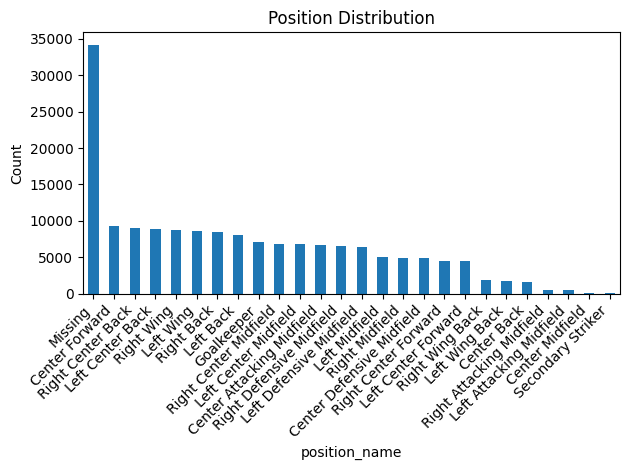

In [13]:
plt.figure()
position_counts.plot(kind="bar")
plt.title("Position Distribution")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [14]:
position_pivot = pd.pivot_table(
    df,
    index="team_name",
    columns="position_name",
    aggfunc="size",
    fill_value=0
)

position_pivot.head()

position_name,Center Attacking Midfield,Center Back,Center Defensive Midfield,Center Forward,Center Midfield,Goalkeeper,Left Attacking Midfield,Left Back,Left Center Back,Left Center Forward,...,Right Attacking Midfield,Right Back,Right Center Back,Right Center Forward,Right Center Midfield,Right Defensive Midfield,Right Midfield,Right Wing,Right Wing Back,Secondary Striker
team_name,,,,,,,,,,,,,,,,,,,,,
AC Ajaccio,1,0,1,4,1,2,0,4,2,4,...,0,2,2,3,2,2,3,4,0,0
AC Milan,39,0,31,20,0,41,2,48,48,58,...,1,53,50,63,46,34,36,14,0,0
AFC Bournemouth,26,0,16,51,0,41,0,41,41,26,...,0,41,43,22,42,15,58,0,0,0
AS Monaco,68,2,16,76,0,41,0,56,58,10,...,0,52,56,17,18,50,22,77,3,0
AS Roma,52,6,40,68,0,38,2,51,52,18,...,3,64,55,17,46,31,18,67,5,0


In [15]:
country_counts = (
    df["country_name"]
    .fillna("Missing")
    .value_counts()
)

country_counts.head(30)

country_name
Spain                       24180
France                      15020
England                     14022
Italy                       11626
Germany                      9964
Brazil                       7335
Argentina                    6191
India                        4076
Netherlands                  3567
Portugal                     3127
United States of America     2401
Switzerland                  2367
Croatia                      2243
Belgium                      2137
Senegal                      2097
Sweden                       1916
Serbia                       1834
Denmark                      1831
Morocco                      1814
Uruguay                      1809
Scotland                     1786
Côte d'Ivoire                1779
Wales                        1721
Ireland                      1525
Colombia                     1438
Nigeria                      1401
Cameroon                     1390
Poland                       1369
Austria                      1355
A

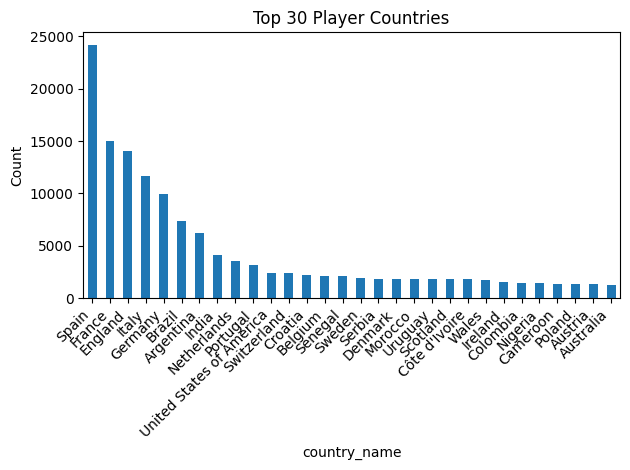

In [16]:
plt.figure()
country_counts.head(30).plot(kind="bar")
plt.title("Top 30 Player Countries")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
country_by_team_pivot = pd.pivot_table(
    df,
    index="team_name",
    columns="country_name",
    aggfunc="size",
    fill_value=0
)

country_by_team_pivot.head(20)

country_name,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Belarus,Belgium,...,Tunisia,Turkey,Ukraine,United States of America,Uruguay,Venezuela (Bolivarian Republic),Vietnam,Wales,Zambia,Zimbabwe
team_name,,,,,,,,,,,,,,,,,,,,,
AC Ajaccio,0,2,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AC Milan,0,0,0,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
AFC Bournemouth,0,0,0,0,0,38,0,0,0,0,...,0,0,0,0,0,0,0,18,0,0
AS Monaco,0,6,40,44,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
AS Roma,0,0,0,48,0,0,0,0,0,73,...,0,29,0,0,0,0,0,0,0,0
ATK Mohun Bagan,0,0,0,0,0,25,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ajax,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Albacete,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,4,0,0,0,0,0
Albania,75,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
top_countries = df["country_name"].value_counts().head(15).index

country_by_team_pivot[top_countries].head()

country_name,Spain,France,England,Italy,Germany,Brazil,Argentina,India,Netherlands,Portugal,United States of America,Switzerland,Croatia,Belgium,Senegal
team_name,,,,,,,,,,,,,,,
AC Ajaccio,0,40,0,0,0,0,0,0,0,0,0,2,0,0,0
AC Milan,36,40,0,601,0,107,1,0,23,1,0,0,0,0,28
AFC Bournemouth,0,52,411,0,0,0,0,0,0,0,0,0,0,0,0
AS Monaco,1,234,0,74,4,146,44,0,1,201,0,2,71,2,9
AS Roma,45,85,0,250,45,74,48,0,17,0,0,0,2,73,0


In [19]:
df["jersey_number"] = pd.to_numeric(df["jersey_number"], errors="coerce")

In [20]:
jersey_counts = df["jersey_number"].value_counts().sort_index()
jersey_counts.head(20)

jersey_number
0      235
1     5517
2     5283
3     5622
4     5965
5     5995
6     6148
7     7132
8     7366
9     6555
10    7489
11    6864
12    3977
13    4931
14    5973
15    5290
16    4985
17    5731
18    5757
19    5718
Name: count, dtype: int64

In [21]:
most_worn_jersey = jersey_counts.idxmax()
most_worn_count = jersey_counts.max()

most_worn_jersey, most_worn_count

(10, 7489)

In [22]:
df["card_type"].value_counts()

card_type
Yellow Card      18217
Second Yellow      697
Red Card           692
Name: count, dtype: int64

In [23]:
card_position_pivot = pd.pivot_table(
    df[df["card_type"].notna()],
    index="position_name",
    columns="card_type",
    aggfunc="size",
    fill_value=0
)

# Add total column
card_position_pivot["Total"] = card_position_pivot.sum(axis=1)

# Sort by total descending
card_position_pivot = card_position_pivot.sort_values(
    by="Total",
    ascending=False
)

card_position_pivot

card_type,Red Card,Second Yellow,Yellow Card,Total
position_name,,,,
Right Center Back,48,57,1561,1666
Left Center Back,38,51,1556,1645
Right Back,34,47,1458,1539
Left Back,24,38,1292,1354
Right Defensive Midfield,31,34,1263,1328
Left Defensive Midfield,27,41,1226,1294
Center Attacking Midfield,182,172,858,1212
Center Defensive Midfield,35,36,1031,1102
Right Center Midfield,25,36,1017,1078


In [24]:
position_totals = df.groupby("position_name").size()

position_card_totals = (
    df[df["card_type"].notna()]
    .groupby("position_name")
    .size()
)

card_rate = (
    position_card_totals / position_totals
).sort_values(ascending=False)

card_rate

position_name
Center Defensive Midfield    0.224486
Right Defensive Midfield     0.203213
Left Defensive Midfield      0.201904
Center Back                  0.191656
Left Center Back             0.185081
Right Center Back            0.184680
Right Back                   0.182541
Center Attacking Midfield    0.182475
Center Midfield              0.168317
Left Back                    0.167099
Right Center Midfield        0.156868
Left Center Midfield         0.150218
Right Wing Back              0.140777
Left Wing Back               0.132997
Left Attacking Midfield      0.130097
Right Midfield               0.121274
Right Attacking Midfield     0.118217
Right Center Forward         0.117252
Left Center Forward          0.115246
Left Midfield                0.111067
Left Wing                    0.107593
Center Forward               0.104987
Right Wing                   0.104670
Secondary Striker            0.097561
Goalkeeper                   0.051643
dtype: float64

In [25]:
player_appearances = (
    df.groupby(["player_id", "player_name"])
      .agg(
          appearances=("match_id", "nunique"),
          team_count=("team_name", "nunique")
      )
      .reset_index()
      .sort_values("appearances", ascending=False)
)

player_appearances.head(20)

,player_id,player_name,appearances,team_count
1209,5503,Lionel Andrés Messi Cuccittini,604,4
1096,5203,Sergio Busquets i Burgos,420,3
1107,5216,Andrés Iniesta Luján,361,2
1104,5213,Gerard Piqué Bernabéu,358,3
1103,5211,Jordi Alba Ramos,284,4
4275,20131,Xavier Hernández Creus,267,1
4293,20176,Víctor Valdés Arribas,257,1
676,4324,Daniel Alves da Silva,250,4
4252,20055,Marc-André ter Stegen,237,2
1212,5506,Javier Alejandro Mascherano,221,3


In [26]:
cards_df = df[df["card_type"].notna()]
player_cards = (
    cards_df.groupby(["player_id", "player_name"])
            .agg(
                total_cards=("card_type", "count"),
                yellow_cards=("card_type", lambda x: (x == "Yellow Card").sum()),
                second_yellow = ("card_type", lambda x: (x == "Second Yellow").sum()),
                red_cards=("card_type", lambda x: (x == "Red Card").sum())
            )
            .reset_index()
            .sort_values("total_cards", ascending=False)
)

player_cards.head(20)

,player_id,player_name,total_cards,yellow_cards,second_yellow,red_cards
666,5203,Sergio Busquets i Burgos,130,129,1,0
673,5213,Gerard Piqué Bernabéu,120,108,9,3
743,5503,Lionel Andrés Messi Cuccittini,77,77,0,0
464,4324,Daniel Alves da Silva,74,68,4,2
672,5211,Jordi Alba Ramos,73,67,5,1
745,5506,Javier Alejandro Mascherano,73,68,2,3
463,4320,Neymar da Silva Santos Junior,48,45,3,0
664,5201,Sergio Ramos García,47,34,7,6
777,5558,Rafael Márquez Álvarez,44,37,6,1
675,5216,Andrés Iniesta Luján,43,43,0,0


In [27]:
min_appearances = 50

#player_card_rate_filtered = player_card_rate[
   # player_card_rate["appearances"] >= min_appearances
#]

#player_card_rate_filtered.sort_values(
 ##   "cards_per_appearance",
#    ascending=False
#).head(20)

In [28]:
df["card_weight"] = 0
df.loc[df["card_type"] == "Yellow Card", "card_weight"] = 1
df.loc[df["card_type"] == "Second Yellow", "card_weight"] = 2
df.loc[df["card_type"] == "Red Card", "card_weight"] = 3

In [29]:
min_matches = 50

team_discipline = (
    df.groupby("team_name")
      .agg(
          total_matches=("match_id", "nunique"),
          total_card_points=("card_weight", "sum"),
          total_cards=("card_type", lambda x: x.notna().sum())
      )
      .reset_index()
)

team_discipline["card_points_per_match"] = (
    team_discipline["total_card_points"] /
    team_discipline["total_matches"]
)

team_discipline["cards_per_match"] = (
    team_discipline["total_cards"] /
    team_discipline["total_matches"]
)

# Apply match threshold
team_discipline_filtered = team_discipline[
    team_discipline["total_matches"] >= min_matches
].copy()

# Top and bottom 5 by card_points_per_match
top5_points = team_discipline_filtered.sort_values(
    "card_points_per_match",
    ascending=False
).head(5)

bottom5_points = team_discipline_filtered.sort_values(
    "card_points_per_match",
    ascending=True
).head(5)

# Top and bottom 5 by cards_per_match
top5_cards = team_discipline_filtered.sort_values(
    "cards_per_match",
    ascending=False
).head(5)

bottom5_cards = team_discipline_filtered.sort_values(
    "cards_per_match",
    ascending=True
).head(5)

print("Top 5 Teams by Card Points per Match")
display(top5_points[["team_name", "total_matches", "card_points_per_match", "cards_per_match"]])

print("Bottom 5 Teams by Card Points per Match")
display(bottom5_points[["team_name", "total_matches", "card_points_per_match", "cards_per_match"]])

print("Top 5 Teams by Cards per Match")
display(top5_cards[["team_name", "total_matches", "card_points_per_match", "cards_per_match"]])

print("Bottom 5 Teams by Cards per Match")
display(bottom5_cards[["team_name", "total_matches", "card_points_per_match", "cards_per_match"]])

Top 5 Teams by Card Points per Match


,team_name,total_matches,card_points_per_match,cards_per_match
124,Granada,50,5.360000,4.900000
98,Espanyol,63,5.142857,4.841270
250,Sevilla,66,4.893939,4.348485
59,Celta Vigo,54,4.796296,4.351852
289,Valencia,65,4.738462,4.246154


Bottom 5 Teams by Card Points per Match


,team_name,total_matches,card_points_per_match,cards_per_match
63,Chelsea FCW,57,0.789474,0.789474
171,Manchester City WFC,59,0.847458,0.813559
49,Bristol City WFC,56,1.035714,1.035714
17,Arsenal WFC,57,1.175439,1.157895
100,Everton LFC,55,1.309091,1.309091


Top 5 Teams by Cards per Match


,team_name,total_matches,card_points_per_match,cards_per_match
124,Granada,50,5.360000,4.900000
98,Espanyol,63,5.142857,4.841270
59,Celta Vigo,54,4.796296,4.351852
250,Sevilla,66,4.893939,4.348485
289,Valencia,65,4.738462,4.246154


Bottom 5 Teams by Cards per Match


,team_name,total_matches,card_points_per_match,cards_per_match
63,Chelsea FCW,57,0.789474,0.789474
171,Manchester City WFC,59,0.847458,0.813559
49,Bristol City WFC,56,1.035714,1.035714
17,Arsenal WFC,57,1.175439,1.157895
100,Everton LFC,55,1.309091,1.309091


## Exploratory Analysis Summary: Global Football Match Data

This exploratory analysis of the `matches.parquet` dataset examined scoring behavior, competitiveness, and contextual influences across global football competitions.

### Overall Match Profile

Across all matches:
- **Average total goals:** ~2.85 per match  
- **Home win rate:** ~45%  
- **Away win rate:** ~31%  
- **Draw rate:** ~23%  
- **Scoreless draw rate:** ~6%  

These results show a consistent home advantage and a moderately high scoring environment. A typical match produces close to 3 goals, and the home team wins nearly half the time.

---

### Competitiveness and Match Dynamics

- **One goal games:** ~35% of matches  
- **Blowouts (3+ goal difference):** ~20% of matches  

This indicates that while football is frequently tightly contested, decisive outcomes are not uncommon. Competitiveness varies across competitions, with some leagues and tournaments demonstrating stronger balance relative to blowout frequency.

International tournaments such as the **FIFA World Cup** and top European leagues such as **Serie A** rank higher in competitive balance compared to others.

---

### League Scoring Identities

Competitions exhibit distinct scoring characteristics:

- **High scoring competitions:**  
  - La Liga  
  - UEFA Women’s Euro  
  - FA Women’s Super League  
  - Indian Super League  

- **Mid scoring competitions:**  
  - Bundesliga  
  - Premier League  
  - Ligue 1  
  - Serie A  

- **Lower scoring competitions:**  
  - African Cup of Nations  

These differences suggest structural variations in playing style, tactical emphasis, and competitive parity across competitions.

---

### Home Advantage Variation

Home advantage exists across all competitions but varies in magnitude. Some competitions show higher home goal shares and stronger home win rates, indicating that environmental factors such as:

- Stadium atmosphere  
- Travel demands  
- Tournament structure  

may influence match outcomes.

---

### Temporal Trends

Scoring trends fluctuate over time rather than following a consistent upward or downward pattern. Rolling averages suggest cyclical scoring eras, with modern football generally clustering between approximately 2.8 and 3.6 goals per match.

Volatility in scoring also shifts across decades, indicating structural evolution in the game.

---

### Predictability and Entropy

Scoreline entropy analysis reveals that some competitions are not only higher scoring but also more unpredictable in outcome distribution. Leagues such as:

- La Liga  
- FA Women’s Super League  
- Bundesliga  

exhibit higher scoreline diversity, reflecting broader variation in match results.

---

### Contextual Influences

Referee and stadium level summaries suggest measurable correlations with goal frequency and outcome patterns. While not causal, these findings reinforce that match environment and officiating context are associated with differences in scoring behavior.

---

## Conclusion

While global football shares common structural characteristics, meaningful differences emerge across competitions, contexts, and time. Scoring intensity, competitive balance, and unpredictability are shaped by league identity, tournament format, and environmental factors.

This analysis highlights that football matches are not homogeneous events, but dynamic systems influenced by structural and contextual variation.

## 1. Data Retrieval

### 1.1 Preprocessing

Load the dataset and standardize key fields used throughout the analysis.


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Set project root (consistent with other notebooks)
PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")

# Load dataset
df = pd.read_parquet(
    PROJECT_ROOT / "data" / "Statsbomb" / "matches.parquet"
)

# Quick look at the data
print(df.head())
print(df.info())
print(df.describe(include="all"))

   match_id  match_date  match_week match_status match_status_360   kickoff  \
0      9880  2018-04-14          32    available        scheduled  16:15:00   
1      9912  2018-04-29          35    available        scheduled  20:45:00   
2      9924  2018-05-06          36    available        scheduled  20:45:00   
3      9855  2018-03-18          29    available        scheduled  16:15:00   
4      9827  2018-03-01          26    available        scheduled  21:00:00   

   home_score  away_score  competition_id competition  ...  \
0           2           1              11     La Liga  ...   
1           2           4              11     La Liga  ...   
2           2           2              11     La Liga  ...   
3           2           0              11     La Liga  ...   
4           1           1              11     La Liga  ...   

  shot_fidelity_version  xy_fidelity_version competition_name  gender  \
0                     2                    2          La Liga    male   
1     

### 1.2 Assumptions and Limitations

Notes to keep in mind when interpreting results
1. Coverage varies by competition, season, and context fields, so comparisons should apply minimum sample filters.
2. Some metadata fields (referee, stadium, kickoff) contain missing values.
3. Any competition with very small match counts can produce noisy rates and should be treated as illustrative only.

## 2. Dataset Overview

### 2.1 Data Integrity Checks

In [32]:
# Basic integrity checks
checks = {}

if "match_id" in df.columns:
    checks["unique_match_id_rate"] = df["match_id"].nunique(dropna=True) / len(df)

if {"home_score", "away_score"}.issubset(df.columns):
    checks["negative_scores_present"] = bool(((df["home_score"] < 0) | (df["away_score"] < 0)).any())

print(pd.Series(checks).to_string())

unique_match_id_rate         1.0
negative_scores_present    False


### 2.2 Data Types and Ranges

In [33]:
# Schema summary
info_df = pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "non_null": df.notna().sum().values,
    "missing": df.isna().sum().values,
    "missing_rate": (df.isna().sum() / len(df)).values
}).sort_values("missing_rate", ascending=False)

print(info_df.head(20).to_string(index=False))


               column   dtype  non_null  missing  missing_rate
  match_available_360  object       425     3039      0.877309
     last_updated_360  object      1828     1636      0.472286
  xy_fidelity_version  object      3218      246      0.071016
shot_fidelity_version  object      3264      200      0.057737
              referee  object      3264      200      0.057737
           referee_id float64      3264      200      0.057737
        home_managers  object      3379       85      0.024538
        away_managers  object      3380       84      0.024249
           stadium_id float64      3454       10      0.002887
              stadium  object      3454       10      0.002887
              kickoff  object      3459        5      0.001443
         data_version  object      3460        4      0.001155
         last_updated  object      3464        0      0.000000
        match_updated  object      3464        0      0.000000
          season_name  object      3464        0      0

### 2.3 Missingness and Completeness

match_available_360      87.73
last_updated_360         47.23
xy_fidelity_version       7.10
shot_fidelity_version     5.77
referee                   5.77
referee_id                5.77
home_managers             2.45
away_managers             2.42
stadium_id                0.29
stadium                   0.29
kickoff                   0.14
data_version              0.12
last_updated              0.00
match_updated             0.00
season_name               0.00
country_name              0.00
is_international          0.00
is_youth                  0.00
gender                    0.00
competition_name          0.00
match_week                0.00
match_status              0.00
match_status_360          0.00
competition_id            0.00
competition               0.00


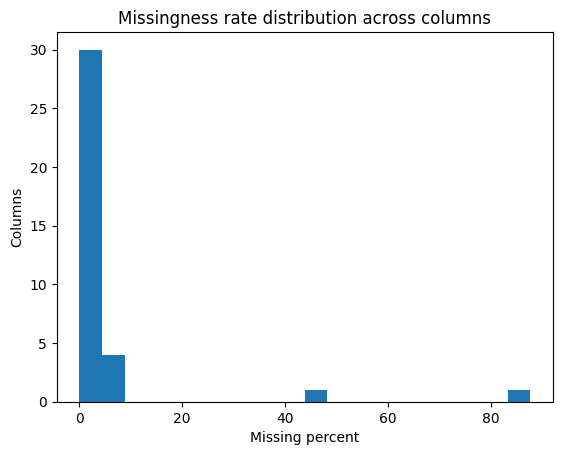

In [34]:
# Missingness profile by column
missing_profile = (df.isna().mean().sort_values(ascending=False) * 100).round(2)
print(missing_profile.head(25).to_string())

plt.figure()
plt.hist(missing_profile.values, bins=20)
plt.title("Missingness rate distribution across columns")
plt.xlabel("Missing percent")
plt.ylabel("Columns")
plt.show()

### 2.4 Descriptive Statistics

In [35]:
# Descriptive stats for numeric columns
num_cols = df.select_dtypes(include=["number", "bool"]).columns.tolist()
if num_cols:
    desc = df[num_cols].describe().T
    print(desc.to_string())
else:
    print("No numeric columns found.")

                 count          mean           std     min         25%        50%         75%        max
match_id        3464.0  2.986350e+06  1.550404e+06  7298.0  3749433.25  3825667.5  3879873.25  4020846.0
match_week      3464.0  1.548557e+01  1.122566e+01     0.0        5.00       14.0       25.00       38.0
home_score      3464.0  1.596420e+00  1.454656e+00     0.0        1.00        1.0        2.00       13.0
away_score      3464.0  1.257217e+00  1.262514e+00     0.0        0.00        1.0        2.00        9.0
competition_id  3464.0  7.982448e+01  2.652113e+02     2.0        9.00       11.0       37.00     1470.0
season_id       3464.0  5.174134e+01  6.273877e+01     1.0       27.00       27.0       42.00      315.0
home_team_id    3464.0  7.555846e+02  1.657017e+03     1.0      171.00      220.0      852.25    29167.0
away_team_id    3464.0  7.788181e+02  1.686822e+03     1.0      171.00      219.0      854.00    29167.0
stadium_id      3454.0  7.787253e+04  2.541042e+05     

### 2.5 Exploratory Visualization

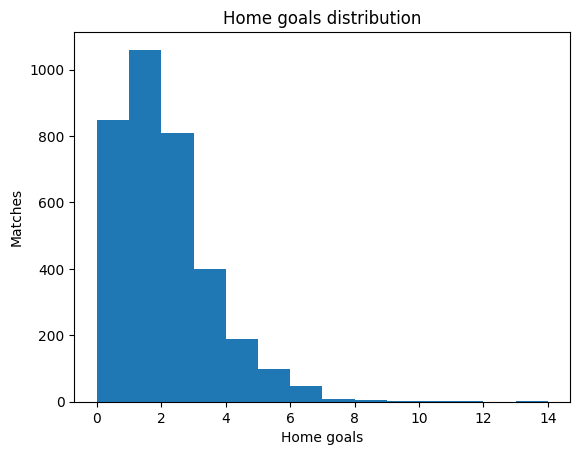

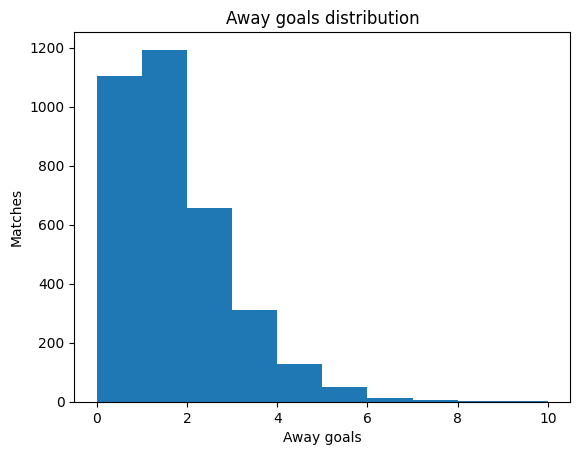

In [36]:
# Quick view of score distributions if present
if {"home_score", "away_score"}.issubset(df.columns):
    plt.figure()
    plt.hist(df["home_score"].dropna(), bins=range(0, int(df["home_score"].max()) + 2))
    plt.title("Home goals distribution")
    plt.xlabel("Home goals")
    plt.ylabel("Matches")
    plt.show()

    plt.figure()
    plt.hist(df["away_score"].dropna(), bins=range(0, int(df["away_score"].max()) + 2))
    plt.title("Away goals distribution")
    plt.xlabel("Away goals")
    plt.ylabel("Matches")
    plt.show()

## 3. Match Outcome and Scoring Profile

Create core match features, then summarize outcomes, competitiveness, scorelines, and total goal distributions.

In [37]:
# Core feature engineering
dt_cols = ["match_date", "kickoff", "last_updated", "match_updated"]
for c in dt_cols:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce")

if {"home_score", "away_score"}.issubset(df.columns):
    df["total_goals"] = df["home_score"].add(df["away_score"])
    df["goal_diff"] = df["home_score"].sub(df["away_score"])

df["home_win"] = (df["goal_diff"] > 0).astype(int)
df["away_win"] = (df["goal_diff"] < 0).astype(int)
df["draw"] = (df["goal_diff"] == 0).astype(int)
df["scoreless_draw"] = ((df["home_score"] == 0) & (df["away_score"] == 0)).astype(int)

if "match_date" in df.columns:
    df["year"] = df["match_date"].dt.year

print(df[["total_goals", "goal_diff", "home_win", "away_win", "draw", "scoreless_draw"]].describe().to_string())

       total_goals    goal_diff     home_win     away_win         draw  scoreless_draw
count  3464.000000  3464.000000  3464.000000  3464.000000  3464.000000     3464.000000
mean      2.853637     0.339203     0.451790     0.318129     0.230081        0.066686
std       1.752256     2.085554     0.497742     0.465817     0.420945        0.249513
min       0.000000    -9.000000     0.000000     0.000000     0.000000        0.000000
25%       2.000000    -1.000000     0.000000     0.000000     0.000000        0.000000
50%       3.000000     0.000000     0.000000     0.000000     0.000000        0.000000
75%       4.000000     2.000000     1.000000     1.000000     0.000000        0.000000
max      13.000000    13.000000     1.000000     1.000000     1.000000        1.000000


C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\4280744992.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[c] = pd.to_datetime(df[c], errors="coerce")


In [38]:
# High level outcome rates
rates = pd.Series({
    "home_win_rate": df["home_win"].mean(),
    "away_win_rate": df["away_win"].mean(),
    "draw_rate": df["draw"].mean(),
    "scoreless_draw_rate": df["scoreless_draw"].mean(),
    "avg_home_goals": df["home_score"].mean(),
    "avg_away_goals": df["away_score"].mean(),
    "avg_total_goals": df["total_goals"].mean(),
}).round(4)

print(rates.to_string())

home_win_rate          0.4518
away_win_rate          0.3181
draw_rate              0.2301
scoreless_draw_rate    0.0667
avg_home_goals         1.5964
avg_away_goals         1.2572
avg_total_goals        2.8536


In [39]:
# Competitiveness metrics
one_goal_rate = (df["goal_diff"].abs() == 1).mean()
blowout_rate = (df["goal_diff"].abs() >= 3).mean()

print("One goal game rate:", round(one_goal_rate, 4))
print("Blowout rate, 3 or more goal diff:", round(blowout_rate, 4))

# Common scorelines
scorelines = (
    df.groupby(["home_score", "away_score"])
      .size()
      .sort_values(ascending=False)
)
print(scorelines.head(15).to_string())

One goal game rate: 0.3533
Blowout rate, 3 or more goal diff: 0.2064
home_score  away_score
1           1             369
            0             312
2           1             288
            0             266
0           1             258
            0             231
1           2             217
0           2             164
2           2             159
3           0             146
            1             142
1           3             101
0           3              98
4           0              77
            1              72


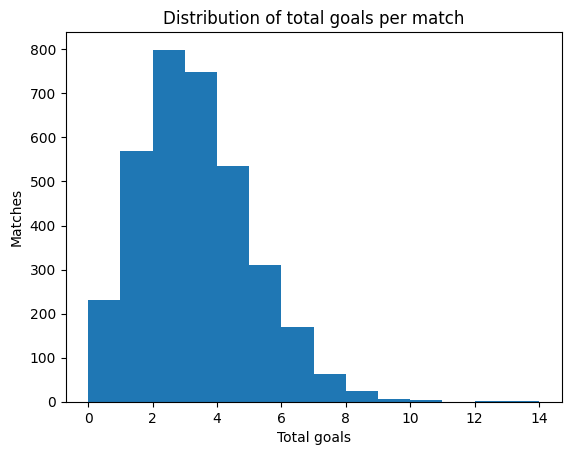

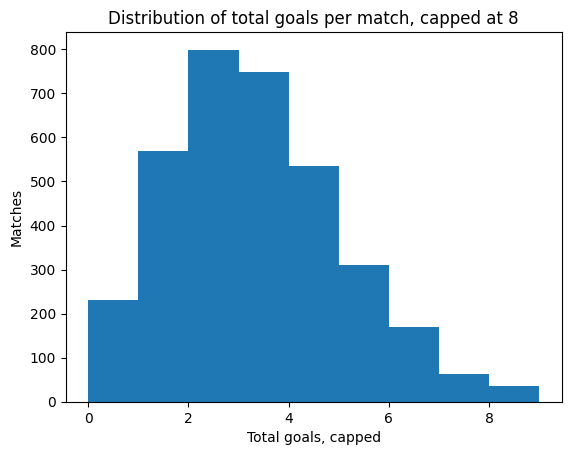

In [40]:
# Total goals distribution
if "total_goals" in df.columns:
    max_goals = int(df["total_goals"].max()) if df["total_goals"].notna().any() else 0

    plt.figure()
    plt.hist(df["total_goals"].dropna(), bins=range(0, max_goals + 2))
    plt.title("Distribution of total goals per match")
    plt.xlabel("Total goals")
    plt.ylabel("Matches")
    plt.show()

    cap = 8
    plt.figure()
    plt.hist(df["total_goals"].dropna().clip(lower=0, upper=cap), bins=range(0, cap + 2))
    plt.title("Distribution of total goals per match, capped at 8")
    plt.xlabel("Total goals, capped")
    plt.ylabel("Matches")
    plt.show()

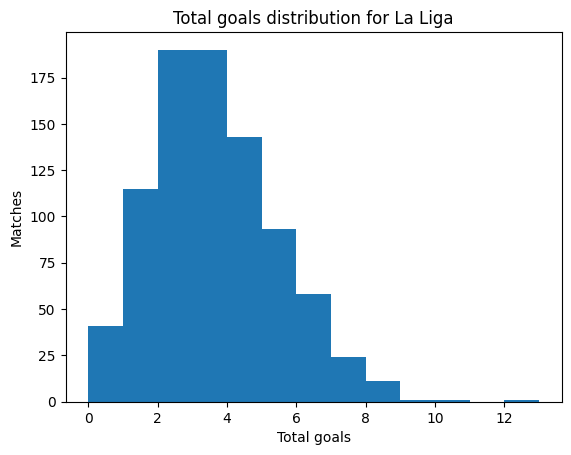

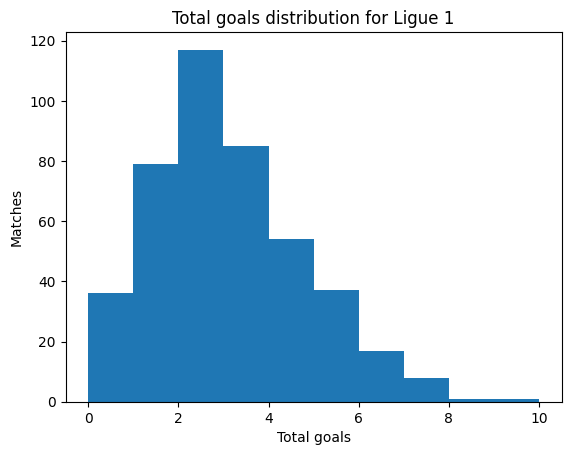

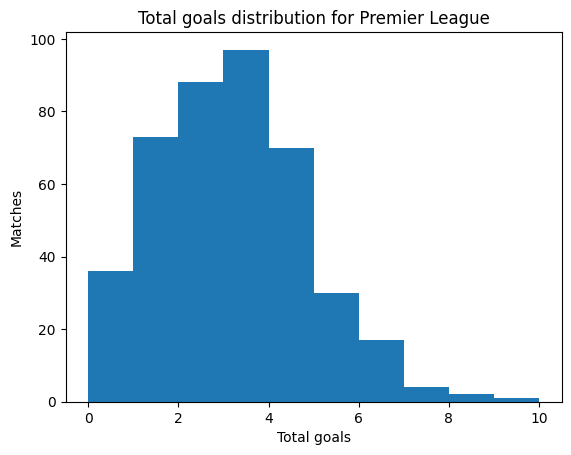

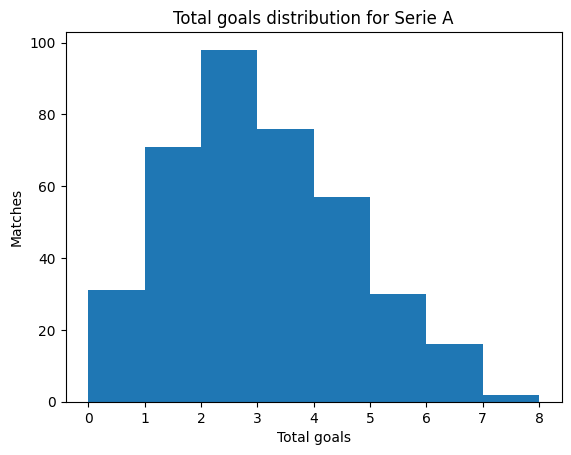

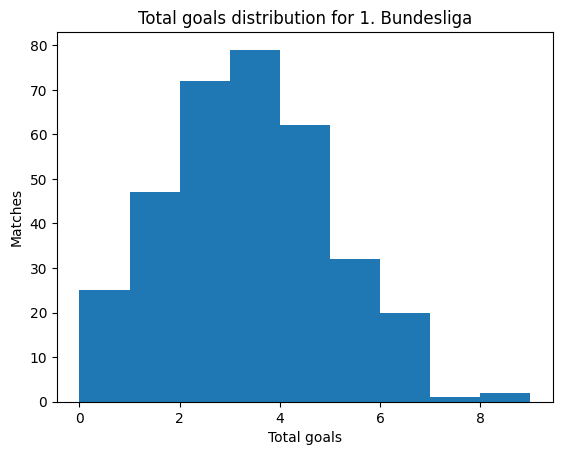

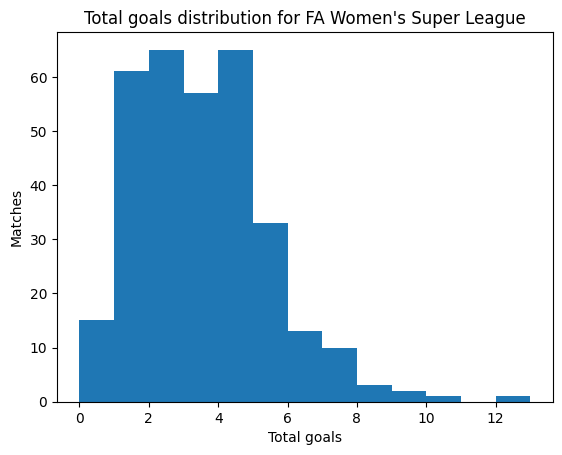

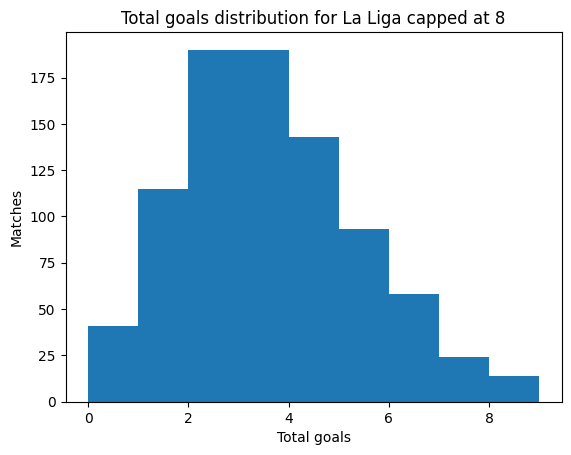

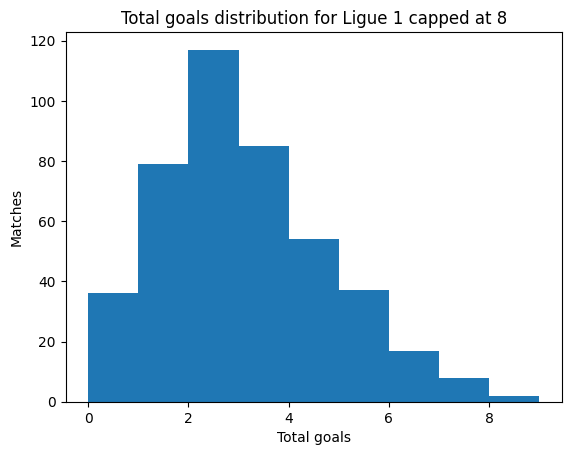

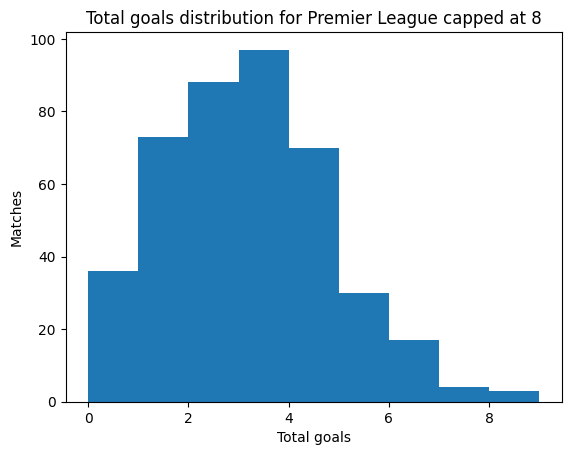

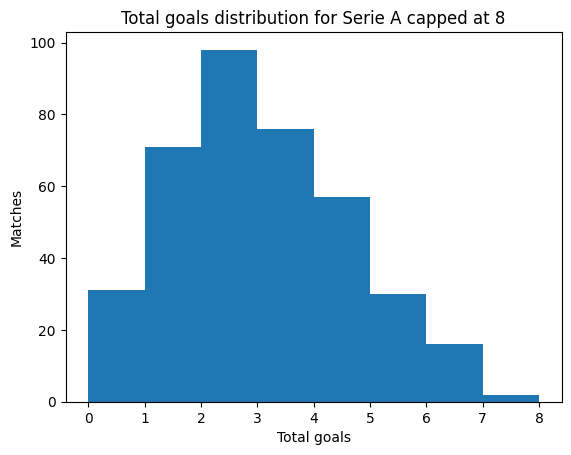

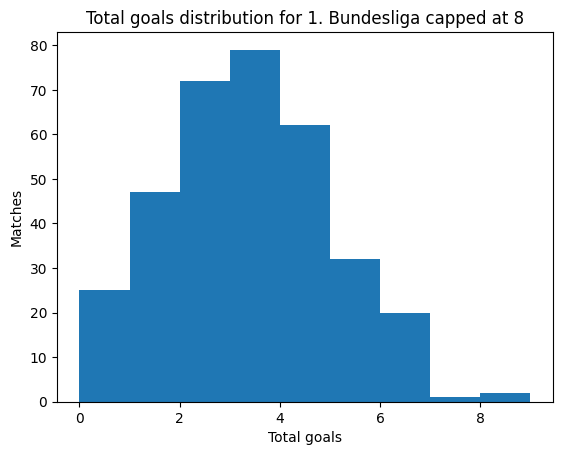

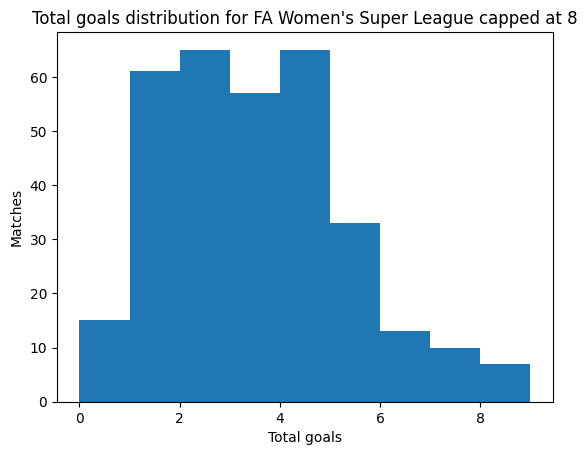

In [41]:
def plot_total_goals_hist_by_group(
    df_in,
    group_col="competition_name",
    top_n=5,
    cap=None,
    bins_max=12
):
    if group_col not in df_in.columns:
        return

    top_groups = (
        df_in[group_col]
        .value_counts(dropna=True)
        .head(top_n)
        .index
        .tolist()
    )

    for g in top_groups:
        sub = df_in[df_in[group_col] == g]["total_goals"].dropna()
        if cap is not None:
            sub = sub.clip(lower=0, upper=cap)

        if sub.empty:
            continue

        max_goals = int(min(sub.max(), bins_max))
        bins = range(0, max_goals + 2)

        plt.figure()
        plt.hist(sub, bins=bins)
        title = f"Total goals distribution for {g}"
        if cap is not None:
            title = f"{title} capped at {cap}"
        plt.title(title)
        plt.xlabel("Total goals")
        plt.ylabel("Matches")
        plt.show()

plot_total_goals_hist_by_group(df, group_col="competition_name", top_n=6, cap=None, bins_max=14)
plot_total_goals_hist_by_group(df, group_col="competition_name", top_n=6, cap=8, bins_max=8)

## 4. Competition and Season Comparisons

Summaries use minimum match thresholds to reduce noise in rate comparisons.

       competition_name  matches  avg_total_goals  avg_home_goals  avg_away_goals  home_win_rate  draw_rate  scoreless_draw_rate
                La Liga      868         3.153226        1.816820        1.336406       0.483871   0.200461             0.047235
                Ligue 1      435         2.629885        1.475862        1.154023       0.429885   0.271264             0.082759
         Premier League      418         2.691388        1.480861        1.210526       0.411483   0.284689             0.086124
                Serie A      381         2.580052        1.469816        1.110236       0.459318   0.249344             0.081365
          1. Bundesliga      340         2.879412        1.585294        1.294118       0.438235   0.226471             0.073529
FA Women's Super League      326         3.064417        1.570552        1.493865       0.432515   0.174847             0.046012
         FIFA World Cup      147         2.761905        1.619048        1.142857       0.476190 

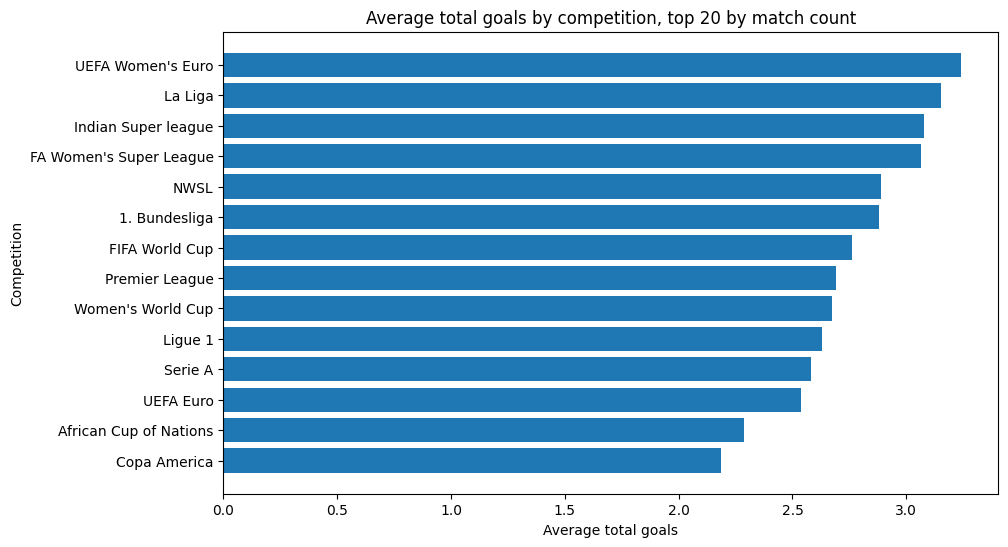

In [42]:
MIN_MATCHES = 30

if "competition_name" in df.columns:
    comp_summary = (
        df.groupby("competition_name")
          .agg(
              matches=("match_id", "count") if "match_id" in df.columns else ("total_goals", "size"),
              avg_total_goals=("total_goals", "mean"),
              avg_home_goals=("home_score", "mean"),
              avg_away_goals=("away_score", "mean"),
              home_win_rate=("home_win", "mean"),
              draw_rate=("draw", "mean"),
              scoreless_draw_rate=("scoreless_draw", "mean"),
          )
          .reset_index()
    )

    comp_summary = comp_summary[comp_summary["matches"] >= MIN_MATCHES].copy()
    comp_summary = comp_summary.sort_values("matches", ascending=False)

    print(comp_summary.head(20).to_string(index=False))

    top20 = comp_summary.sort_values("matches", ascending=False).head(20).copy()
    top20 = top20.sort_values("avg_total_goals", ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(top20["competition_name"], top20["avg_total_goals"])
    plt.title("Average total goals by competition, top 20 by match count")
    plt.xlabel("Average total goals")
    plt.ylabel("Competition")
    plt.show()

season_name  matches  avg_total_goals  home_win_rate  draw_rate
  2015/2016     1824         2.667215       0.444079   0.259868
  2020/2021      166         3.198795       0.397590   0.210843
  2018/2019      143         3.090909       0.412587   0.167832
  2021/2022      141         3.106383       0.425532   0.283688
       2023      122         2.418033       0.459016   0.278689
  2019/2020      120         3.016667       0.533333   0.150000
       2018      100         2.730000       0.420000   0.190000
       2022       95         2.810526       0.526316   0.210526
       2024       83         2.253012       0.409639   0.313253
       2019       52         2.807692       0.538462   0.076923
       2020       51         2.784314       0.333333   0.235294
  2003/2004       39         2.615385       0.384615   0.307692
  2014/2015       39         3.461538       0.461538   0.102564
  2011/2012       38         3.710526       0.473684   0.210526
  2017/2018       37         3.270270   

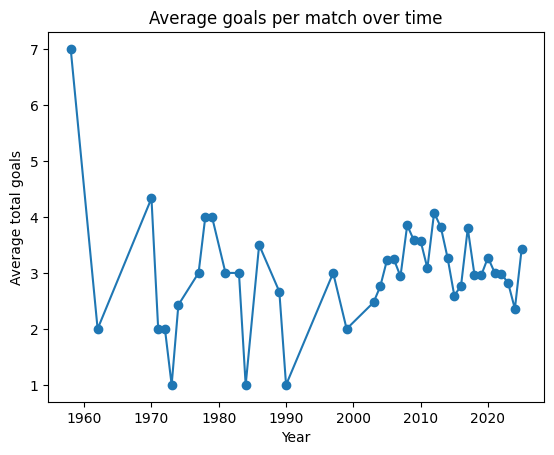

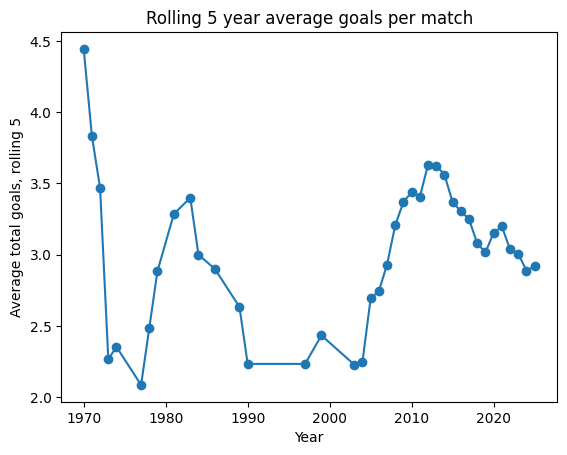

In [43]:
MIN_MATCHES = 0

if "season_name" in df.columns:
    season_summary = (
        df.groupby("season_name")
          .agg(
              matches=("match_id", "count") if "match_id" in df.columns else ("total_goals", "size"),
              avg_total_goals=("total_goals", "mean"),
              home_win_rate=("home_win", "mean"),
              draw_rate=("draw", "mean"),
          )
          .reset_index()
    )

    season_summary = season_summary[season_summary["matches"] >= MIN_MATCHES].copy()
    season_summary = season_summary.sort_values("matches", ascending=False)

    print(season_summary.head(20).to_string(index=False))

if "year" in df.columns:
    goals_by_year = df.groupby("year")["total_goals"].mean().sort_index()
    plt.figure()
    plt.plot(goals_by_year.index, goals_by_year.values, marker="o")
    plt.title("Average goals per match over time")
    plt.xlabel("Year")
    plt.ylabel("Average total goals")
    plt.show()

    rolling_5 = goals_by_year.rolling(window=5, min_periods=3).mean()
    plt.figure()
    plt.plot(rolling_5.index, rolling_5.values, marker="o")
    plt.title("Rolling 5 year average goals per match")
    plt.xlabel("Year")
    plt.ylabel("Average total goals, rolling 5")
    plt.show()

## 5. Context Comparisons

In [44]:
# Context splits
if "is_international" in df.columns:
    print("Average total goals by domestic and international")
    print(df.groupby("is_international")["total_goals"].mean().round(4).to_string())

if "is_youth" in df.columns:
    print("Average total goals by youth flag")
    print(df.groupby("is_youth")["total_goals"].mean().round(4).to_string())

if "gender" in df.columns:
    print("Average total goals by gender")
    print(df.groupby("gender")["total_goals"].mean().round(4).to_string())

Average total goals by domestic and international
is_international
False    2.8848
True     2.6738
Average total goals by youth flag
is_youth
False    2.8533
True     4.0000
Average total goals by gender
gender
female    2.9889
male      2.8287


## 6. Advanced Metrics

Includes parity metrics, conditional probabilities, scoreline entropy, and optional referee and stadium effects.

In [45]:
# Parity and balance metrics per competition
MIN_MATCHES = 50

if "competition_name" in df.columns:
    parity = (
        df.groupby("competition_name")
          .agg(
              matches=("match_id", "count") if "match_id" in df.columns else ("total_goals", "size"),
              avg_total_goals=("total_goals", "mean"),
              std_goal_diff=("goal_diff", "std"),
              one_goal_rate=("goal_diff", lambda s: (s.abs() == 1).mean()),
              blowout_rate=("goal_diff", lambda s: (s.abs() >= 3).mean()),
              draw_rate=("draw", "mean"),
              home_win_rate=("home_win", "mean"),
          )
          .reset_index()
    )

    parity = parity[parity["matches"] >= MIN_MATCHES].copy()
    parity["competitive_index"] = parity["one_goal_rate"].sub(parity["blowout_rate"])

    print("Most competitive by competitive index, matches at least 50")
    print(parity.sort_values("competitive_index", ascending=False).head(15).to_string(index=False))

# Conditional outcome rates
df["high_scoring"] = (df["total_goals"] >= 4).astype(int)
df["low_scoring"] = (df["total_goals"] <= 1).astype(int)

print("Outcome rates given high scoring")
print(df.groupby("high_scoring")[["home_win", "away_win", "draw"]].mean().round(4).to_string())

print("Outcome rates given low scoring")
print(df.groupby("low_scoring")[["home_win", "away_win", "draw"]].mean().round(4).to_string())

# Scoreline entropy per competition
def scoreline_entropy(g):
    counts = g.groupby(["home_score", "away_score"]).size()
    probs = counts.div(counts.sum())
    return float(np.negative((probs.mul(np.log2(probs))).sum()))

if "competition_name" in df.columns:
    ent = (
        df.groupby("competition_name")
          .apply(lambda g: pd.Series({
              "matches": len(g),
              "scoreline_entropy": scoreline_entropy(g),
              "avg_total_goals": g["total_goals"].mean(),
          }))
          .reset_index()
    )

    ent = ent[ent["matches"] >= MIN_MATCHES].copy()
    print("Highest scoreline entropy, matches at least 50")
    print(ent.sort_values("scoreline_entropy", ascending=False).head(15).to_string(index=False))

# Optional referee and stadium effects with sample guard
MIN_EFFECT_MATCHES = 30

if "referee" in df.columns:
    ref = (
        df.groupby("referee")
          .agg(
              matches=("total_goals", "size"),
              avg_total_goals=("total_goals", "mean"),
              draw_rate=("draw", "mean"),
          )
          .reset_index()
    )
    ref = ref[ref["matches"] >= MIN_EFFECT_MATCHES].copy()
    print("Referees with highest avg total goals, matches at least 30")
    print(ref.sort_values("avg_total_goals", ascending=False).head(10).to_string(index=False))

if "stadium" in df.columns:
    stad = (
        df.groupby("stadium")
          .agg(
              matches=("total_goals", "size"),
              avg_total_goals=("total_goals", "mean"),
              home_win_rate=("home_win", "mean"),
          )
          .reset_index()
    )
    stad = stad[stad["matches"] >= MIN_EFFECT_MATCHES].copy()
    print("Stadiums with highest avg total goals, matches at least 30")
    print(stad.sort_values("avg_total_goals", ascending=False).head(10).to_string(index=False))


Most competitive by competitive index, matches at least 50
       competition_name  matches  avg_total_goals  std_goal_diff  one_goal_rate  blowout_rate  draw_rate  home_win_rate  competitive_index
         FIFA World Cup      147         2.761905       1.783998       0.421769      0.149660   0.197279       0.476190           0.272109
                Serie A      381         2.580052       1.680960       0.385827      0.125984   0.249344       0.459318           0.259843
              UEFA Euro      102         2.539216       1.684289       0.382353      0.147059   0.284314       0.352941           0.235294
 African Cup of Nations       52         2.288462       1.448331       0.326923      0.115385   0.384615       0.384615           0.211538
         Premier League      418         2.691388       1.723342       0.375598      0.165072   0.284689       0.411483           0.210526
    Indian Super league      115         3.078261       1.824990       0.365217      0.165217   0.286957   

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1329967129.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


Top competitions by scoreline entropy matches >= 50
           competition_name  matches  scoreline_entropy  avg_total_goals
9                   La Liga    868.0           4.652638         3.153226
5   FA Women's Super League    326.0           4.583335         3.064417
0             1. Bundesliga    340.0           4.347724         2.879412
8       Indian Super league    115.0           4.263834         3.078261
11                  Ligue 1    435.0           4.253167         2.629885
15           Premier League    418.0           4.235359         2.691388
7            FIFA World Cup    147.0           4.154109         2.761905
20        Women's World Cup    116.0           4.140968         2.672414
16                  Serie A    381.0           4.138192         2.580052
17                UEFA Euro    102.0           3.984952         2.539216
19        UEFA Women's Euro     62.0           3.963500         3.241935
1    African Cup of Nations     52.0           3.540577         2.288462

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\654721549.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


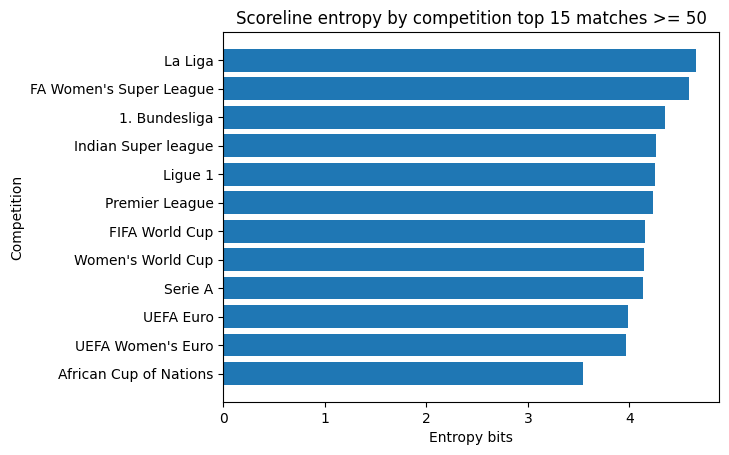

In [46]:
# Measures how diverse scorelines are within a competition
def scoreline_entropy(group_df):
    counts = group_df.groupby(["home_score", "away_score"]).size()
    probs = counts / counts.sum()
    return float(-(probs * np.log2(probs)).sum())

if "competition_name" in df.columns:
    ent = (
        df.groupby("competition_name")
        .apply(lambda g: pd.Series({
            "matches": len(g),
            "scoreline_entropy": scoreline_entropy(g),
            "avg_total_goals": g["total_goals"].mean()
        }))
        .reset_index()
    )

    ent = ent[ent["matches"] >= 50].copy()

    print("Top competitions by scoreline entropy matches >= 50")
    print(ent.sort_values("scoreline_entropy", ascending=False).head(20))

    plt.figure()
    top = ent.sort_values("scoreline_entropy", ascending=False).head(15)
    plt.barh(top["competition_name"], top["scoreline_entropy"])
    plt.title("Scoreline entropy by competition top 15 matches >= 50")
    plt.xlabel("Entropy bits")
    plt.ylabel("Competition")
    plt.gca().invert_yaxis()
    plt.show()


In [47]:
df["high_scoring"] = (df["total_goals"] >= 4).astype(int)
df["low_scoring"] = (df["total_goals"] <= 1).astype(int)

print("Conditional outcome rates overall")
print(df.groupby("high_scoring")[["home_win", "away_win", "draw"]].mean())
print(df.groupby("low_scoring")[["home_win", "away_win", "draw"]].mean())

# Conditional by competition for enough sample sizes
if "competition_name" in df.columns:
    cond_by_comp = (
        df.groupby("competition_name")
        .apply(
            lambda g: pd.Series({
                "matches": len(g),
                "home_win_given_high_scoring": g.loc[g["high_scoring"] == 1, "home_win"].mean(),
                "draw_given_low_scoring": g.loc[g["low_scoring"] == 1, "draw"].mean(),
                "high_scoring_rate": g["high_scoring"].mean(),
                "low_scoring_rate": g["low_scoring"].mean(),
            })
        )
        .reset_index()
    )

    cond_by_comp = cond_by_comp[cond_by_comp["matches"] >= 50].copy()

    print("Competitions with highest home win given high scoring, matches >= 50")
    print(cond_by_comp.sort_values("home_win_given_high_scoring", ascending=False).head(15))

    print("Competitions with highest draw given low scoring, matches >= 50")
    print(cond_by_comp.sort_values("draw_given_low_scoring", ascending=False).head(15))



Conditional outcome rates overall
              home_win  away_win      draw
high_scoring                              
0             0.430822  0.313751  0.255428
1             0.495964  0.327354  0.176682
             home_win  away_win      draw
low_scoring                              
0            0.470522  0.316936  0.212542
1            0.389513  0.322097  0.288390
Competitions with highest home win given high scoring, matches >= 50
           competition_name  matches  home_win_given_high_scoring  \
19        UEFA Women's Euro     62.0                     0.727273   
7            FIFA World Cup    147.0                     0.675676   
9                   La Liga    868.0                     0.530120   
20        Women's World Cup    116.0                     0.517241   
0             1. Bundesliga    340.0                     0.487179   
11                  Ligue 1    435.0                     0.483051   
16                  Serie A    381.0                     0.476190   
8    

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\360769704.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [48]:

# Create a simple competitiveness bucket per match
df["tight_game"] = (df["goal_diff"].abs() <= 1).astype(int)
df["blowout_game"] = (df["goal_diff"].abs() >= 3).astype(int)

print("Outcome and competitiveness by total goals bucket")
df["total_goals_bucket"] = pd.cut(
    df["total_goals"],
    bins=[-0.1, 1, 2, 3, 4, 5, 1000],
    labels=["0-1", "2", "3", "4", "5", "6+"]
)

bucket_summary = (
    df.groupby("total_goals_bucket")
    .agg(
        matches=("total_goals", "size"),
        home_win_rate=("home_win", "mean"),
        away_win_rate=("away_win", "mean"),
        draw_rate=("draw", "mean"),
        tight_rate=("tight_game", "mean"),
        blowout_rate=("blowout_game", "mean"),
        avg_goal_diff=("goal_diff", "mean"),
    )
    .reset_index()
)

print(bucket_summary)

Outcome and competitiveness by total goals bucket
  total_goals_bucket  matches  home_win_rate  away_win_rate  draw_rate  \
0                0-1      801       0.389513       0.322097   0.288390   
1                  2      799       0.332916       0.205257   0.461827   
2                  3      749       0.579439       0.420561   0.000000   
3                  4      535       0.409346       0.293458   0.297196   
4                  5      311       0.585209       0.414791   0.000000   
5                 6+      269       0.565056       0.293680   0.141264   

   tight_rate  blowout_rate  avg_goal_diff  
0    1.000000      0.000000       0.067416  
1    0.461827      0.000000       0.255319  
2    0.674232      0.325768       0.287049  
3    0.297196      0.248598       0.310280  
4    0.421222      0.578778       0.627010  
5    0.208178      0.587361       1.267658  


C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\3830048885.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("total_goals_bucket")


# Soccer Trades Market  Analysis

## Dataset Overview

This dataset contains approximately 1.13 million trades across 3,245 markets and 4,515 tokens. Core fields such as trade ID, market ID, timestamp, price, and size contain no missing values or duplicate trade IDs, indicating strong structural integrity. Some participant address fields contain missing values, but this does not materially affect trade level analysis.

## Market Activity Distribution

Trading activity is highly concentrated. While the average number of trades per market is about 351, the median is only 70, and the maximum exceeds 29,000. This large gap between mean and median indicates a strongly right skewed distribution.

Most markets are lightly traded, while a small subset accounts for the majority of volume. Liquidity is therefore fragmented and concentrated in a limited number of high activity markets.

## Price Behavior

Prices range between 0 and 1 and cluster around three regions: near 0, near 0.5, and near 1. The region around 0.5 reflects uncertainty, while clustering near 0 or 1 reflects strong conviction.

Minute level charts show relatively stable prices followed by sharp jumps. These abrupt moves likely correspond to information events or concentrated directional trading.

## Intraday Volume and Activity

Trades per minute and volume per minute display bursty patterns rather than smooth continuous flow. Periods of low activity are interrupted by sharp spikes in both trade count and volume.

This suggests episodic liquidity driven by events or coordinated participation rather than steady institutional style trading.

## VWAP vs Last Price

Comparing last trade price per minute with VWAP reveals that last prices are more volatile. In several cases, last price spikes sharply while VWAP remains relatively stable.

This indicates that individual aggressive trades can temporarily move prices in thin liquidity conditions, without broad capital confirming the move.

## Order Flow Imbalance

Signed volume per minute shows large positive and negative spikes corresponding to aggressive buying or selling pressure. Price jumps frequently align with these imbalance spikes, suggesting that short term price movement is flow driven.

This behavior is consistent with microstructure dynamics where aggressive order flow moves prices in fragmented liquidity environments.

## Participant Concentration

Wallet level activity is highly skewed. Most addresses trade infrequently, while a small number execute thousands of trades. This concentration implies that a limited group of participants drives a disproportionate share of activity.

## Overall Findings

The market exhibits concentrated liquidity, burst driven trading behavior, flow sensitive pricing, and participant concentration. Price dynamics are strongly influenced by aggressive order flow, particularly in thin liquidity conditions. Overall, the ecosystem behaves as an event driven and fragmented microstructure rather than a continuously liquid market.

## 1 Data Retrieval

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set project root (same as other notebooks)
PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")

# Load dataset
df = pd.read_parquet(
    PROJECT_ROOT / "data" / "Polymarket" / "soccer_trades.parquet"
)

# Shape
df.shape

(1138914, 9)

In [52]:
df.head()

,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address
0,0xdb64fc3e414c94ebc9df9512a4437ef419299e51697d...,598918,8493648277636439482059305825680680269562039180...,1970-01-21 08:22:38.248,0.71,1.830984,SELL,0x2382bc1a87a891090a5a4f43ba30e013ceb04628,0xe3282069bf386acedfa36e283826d8a362159f4a
1,0xd9338105b6e933c18f8ea7a791a3f6b65703854d9742...,598918,8493648277636439482059305825680680269562039180...,1970-01-21 08:22:52.520,0.69,14.492752,SELL,0x94fb389d0f9d3686b363b8bbf30ec240ce97d6cb,0x0619d45d46680165269ba8b1e62dc1bd3a35fe26
2,0xf3c9ee5fdd9bc371a73ed65344e81fb72db4b4b42711...,598918,8493648277636439482059305825680680269562039180...,1970-01-21 08:22:54.758,0.69,1.810000,SELL,0x94fb389d0f9d3686b363b8bbf30ec240ce97d6cb,0x99b583eb0a8d6f305d50094da50487c43d33482a
3,0x899bb153e4bb1f54c5006295ca8a1725ca15b88f79d0...,598918,8493648277636439482059305825680680269562039180...,1970-01-21 08:23:03.508,0.68,38.382351,SELL,0x94fb389d0f9d3686b363b8bbf30ec240ce97d6cb,0x1947814e058caa2ee0844baac3c84853aef094bc
4,0x88248af71412f3026737896bf40ea1ca69212628b693...,598918,8493648277636439482059305825680680269562039180...,1970-01-21 08:23:11.292,0.68,1.470587,SELL,0x94fb389d0f9d3686b363b8bbf30ec240ce97d6cb,0xd261f0c94a729f932fe652c0787f293af2ce13c1


In [53]:
df.dtypes

trade_id                 object
market_id                object
token_id                 object
timestamp        datetime64[us]
price                   float64
size                    float64
side                     object
maker_address            object
taker_address            object
dtype: object

## 2 Dataset Overview and Integrity Checks

In [54]:
df.isnull().sum()

trade_id            0
market_id           0
token_id            0
timestamp           0
price               0
size                0
side                0
maker_address    1586
taker_address    4895
dtype: int64

In [55]:
df["trade_id"].duplicated().sum()

0

In [56]:
df["price"].describe()

count    1.138914e+06
mean     5.153840e-01
std      3.401703e-01
min      1.000000e-03
25%      2.200000e-01
50%      5.200000e-01
75%      8.200000e-01
max      9.990000e-01
Name: price, dtype: float64

In [57]:
df[(df["price"] < 0) | (df["price"] > 1)].head()

,trade_id,market_id,token_id,timestamp,price,size,side,maker_address,taker_address


## 3 Market Structure

In [58]:
n_markets = df["market_id"].nunique()
n_tokens = df["token_id"].nunique()

n_markets, n_tokens


(3245, 4515)

In [59]:
trades_per_market = df.groupby("market_id").size().sort_values(ascending=False)
trades_per_market.describe()

count     3245.000000
mean       350.975039
std        936.898568
min          1.000000
25%         19.000000
50%         70.000000
75%        279.000000
max      29335.000000
dtype: float64

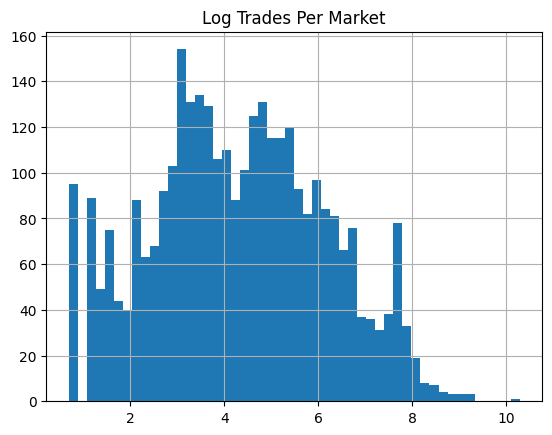

In [60]:
plt.figure()
np.log1p(trades_per_market).hist(bins=50)
plt.title("Log Trades Per Market")
plt.show()

In [61]:
volume_per_market = df.groupby("market_id")["size"].sum().sort_values(ascending=False)
volume_per_market.describe()

count    3.245000e+03
mean     1.029738e+05
std      3.215153e+05
min      1.020400e+00
25%      1.118922e+03
50%      7.969683e+03
75%      5.822487e+04
max      8.004991e+06
Name: size, dtype: float64

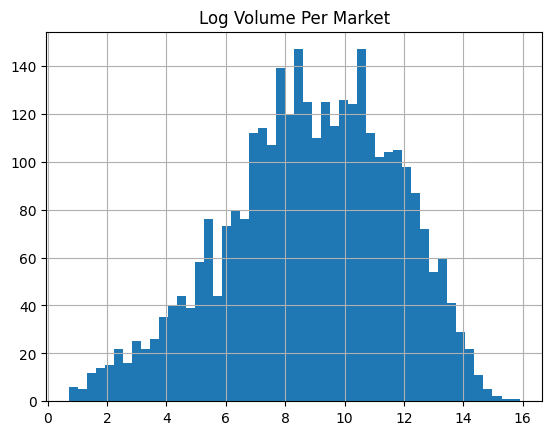

In [62]:
plt.figure()
np.log1p(volume_per_market).hist(bins=50)
plt.title("Log Volume Per Market")
plt.show()

## 4 Trade Behavior

In [63]:
df["side"].value_counts()

side
BUY     935599
SELL    203315
Name: count, dtype: int64

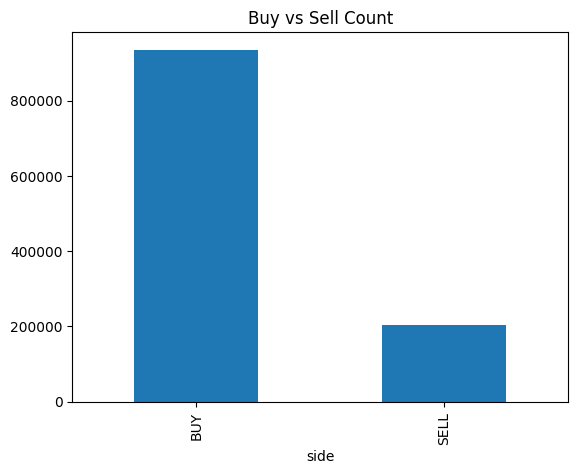

In [64]:
plt.figure()
df["side"].value_counts().plot(kind="bar")
plt.title("Buy vs Sell Count")
plt.show()

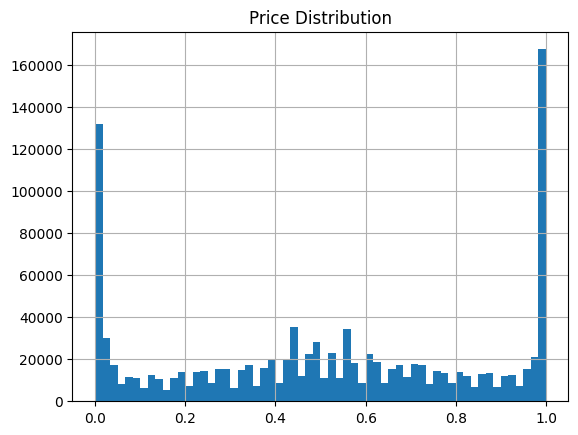

In [65]:
plt.figure()
df["price"].hist(bins=60)
plt.title("Price Distribution")
plt.show()

In [66]:
df.groupby("side")["price"].describe()

,count,mean,std,min,25%,50%,75%,max
side,,,,,,,,
BUY,935599.0,0.511411,0.332472,0.001,0.24,0.51,0.790,0.999
SELL,203315.0,0.533669,0.373010,0.001,0.15,0.55,0.958,0.999


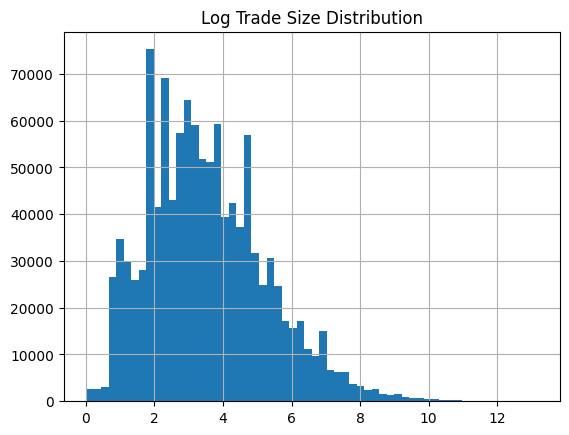

In [67]:
plt.figure()
np.log1p(df["size"]).hist(bins=60)
plt.title("Log Trade Size Distribution")
plt.show()

## 5 Timestamp Handling and Time Based Aggregations

In [68]:
df["timestamp"].dtype

dtype('<M8[us]')

In [69]:
if not np.issubdtype(df["timestamp"].dtype, np.datetime64):
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df["timestamp"].min(), df["timestamp"].max()

(Timestamp('1970-01-21 04:26:53.333000'),
 Timestamp('1970-01-21 10:59:54.797000'))

In [70]:
df = df.sort_values("timestamp").copy()
df["minute"] = df["timestamp"].dt.floor("min")

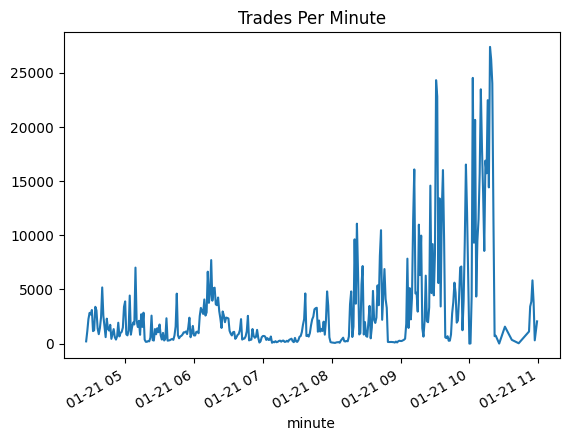

In [71]:
trades_per_minute = df.groupby("minute").size().sort_index()

plt.figure()
trades_per_minute.plot()
plt.title("Trades Per Minute")
plt.show()

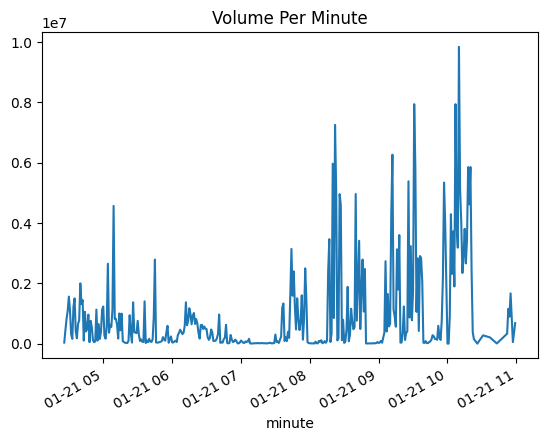

minute
1970-01-21 10:10:00    9.836156e+06
1970-01-21 09:31:00    7.938164e+06
1970-01-21 10:07:00    7.937734e+06
1970-01-21 08:22:00    7.250424e+06
1970-01-21 09:12:00    6.262459e+06
1970-01-21 08:20:00    5.964978e+06
1970-01-21 10:20:00    5.853960e+06
1970-01-21 10:18:00    5.850785e+06
1970-01-21 09:32:00    5.827823e+06
1970-01-21 09:26:00    5.382218e+06
Name: size, dtype: float64

In [72]:
volume_per_minute = df.groupby("minute")["size"].sum().sort_index()

plt.figure()
volume_per_minute.plot()
plt.title("Volume Per Minute")
plt.show()

volume_per_minute.sort_values(ascending=False).head(10)

## 6 Price Trajectories for Major Markets

In [73]:
top_n = 5

top_markets = trades_per_market.head(top_n).index.tolist()
top_markets

['672130', '547980', '639459', '672180', '652170']

In [74]:
def vwap(group: pd.DataFrame) -> float:
    total_size = group["size"].sum()
    if total_size == 0:
        return np.nan
    return (group["price"] * group["size"]).sum() / total_size

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1025999959.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_price = m_df.groupby("minute").apply(vwap).sort_index()


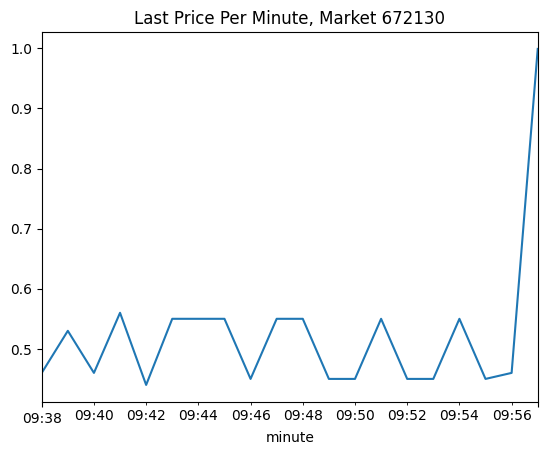

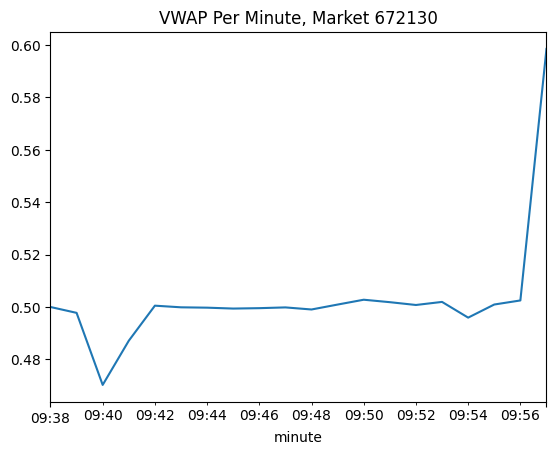

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1025999959.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_price = m_df.groupby("minute").apply(vwap).sort_index()


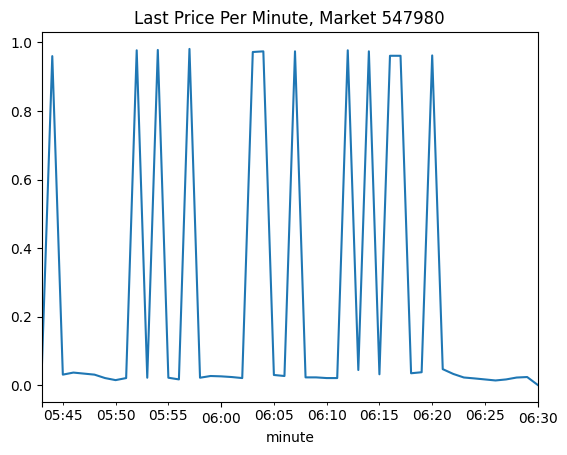

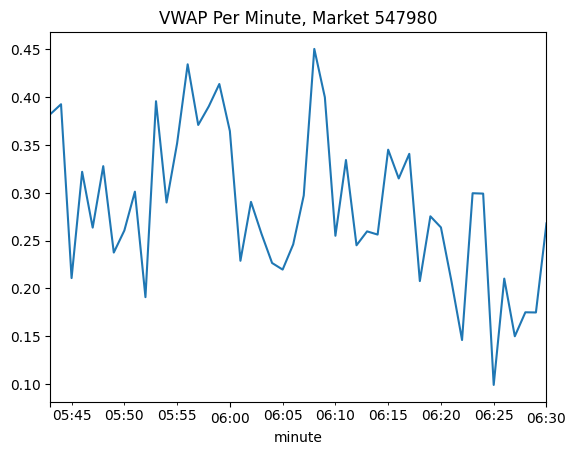

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1025999959.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_price = m_df.groupby("minute").apply(vwap).sort_index()


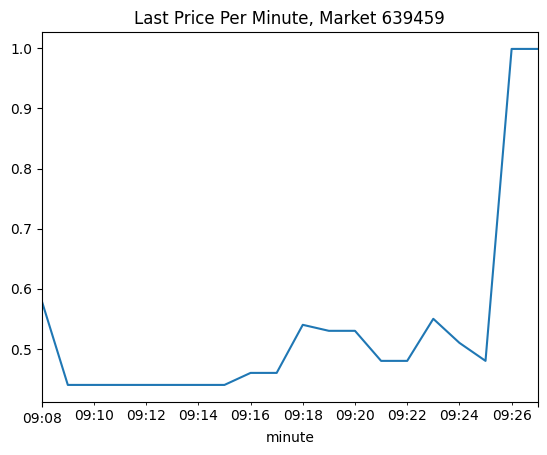

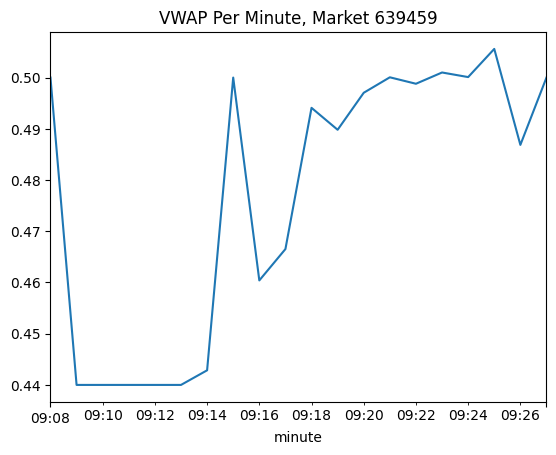

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1025999959.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_price = m_df.groupby("minute").apply(vwap).sort_index()


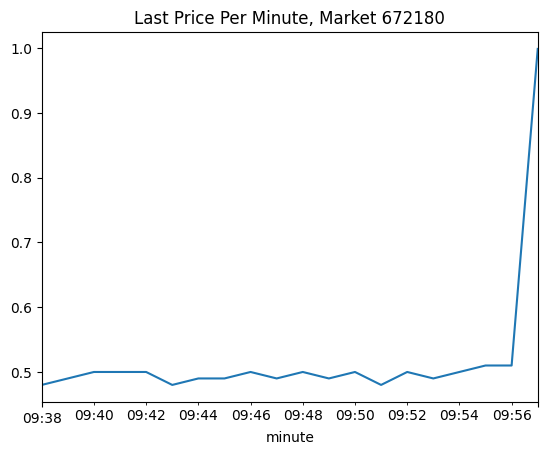

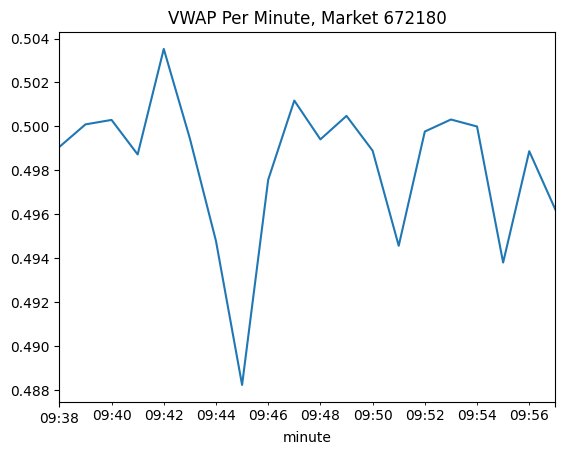

C:\Users\bapna\AppData\Local\Temp\ipykernel_31748\1025999959.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  vwap_price = m_df.groupby("minute").apply(vwap).sort_index()


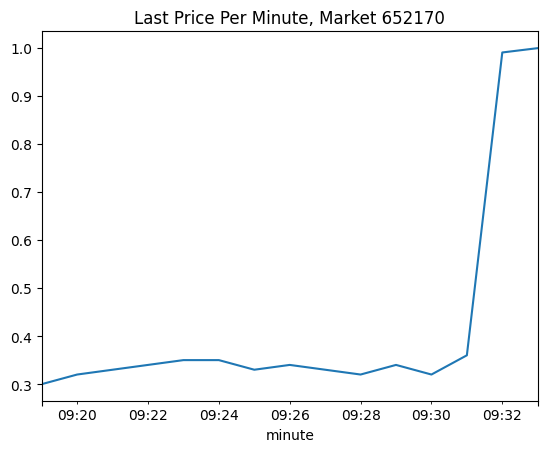

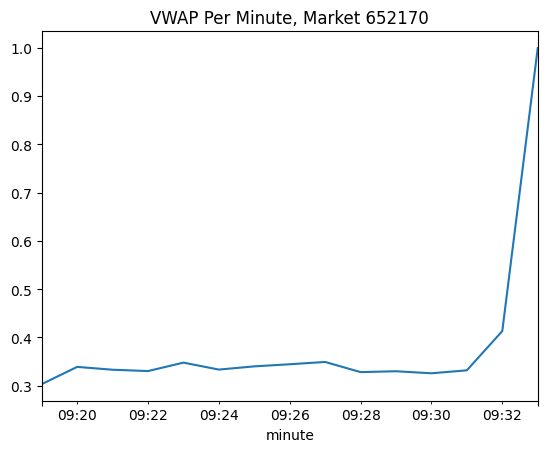

In [75]:
for m in top_markets:
    m_df = df[df["market_id"] == m]
    last_price = m_df.groupby("minute")["price"].last().sort_index()
    vwap_price = m_df.groupby("minute").apply(vwap).sort_index()

    plt.figure()
    last_price.plot()
    plt.title(f"Last Price Per Minute, Market {m}")
    plt.show()

    plt.figure()
    vwap_price.plot()
    plt.title(f"VWAP Per Minute, Market {m}")
    plt.show()

## 7 Order Flow Imbalance

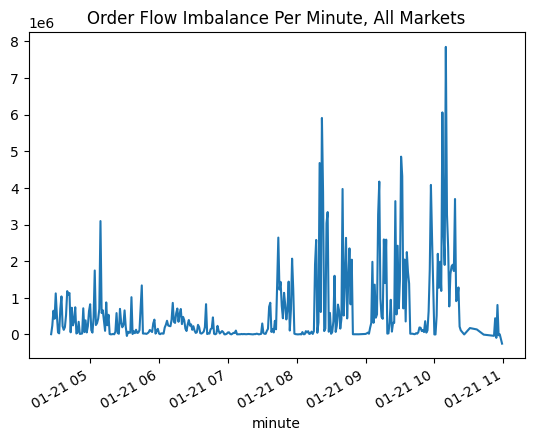

In [76]:
df["signed_volume"] = np.where(df["side"] == "BUY", df["size"], -df["size"])

imbalance_per_minute = df.groupby("minute")["signed_volume"].sum().sort_index()

plt.figure()
imbalance_per_minute.plot()
plt.title("Order Flow Imbalance Per Minute, All Markets")
plt.show()

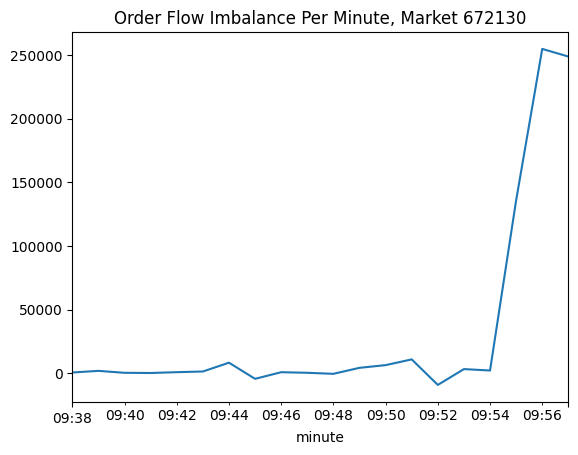

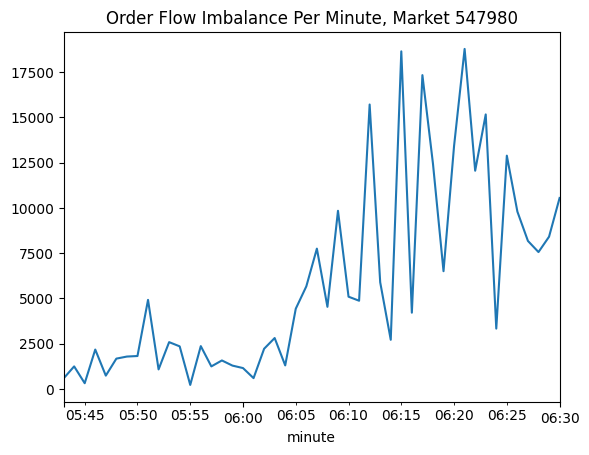

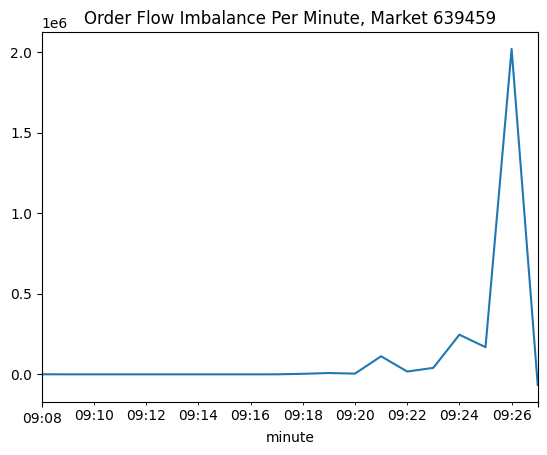

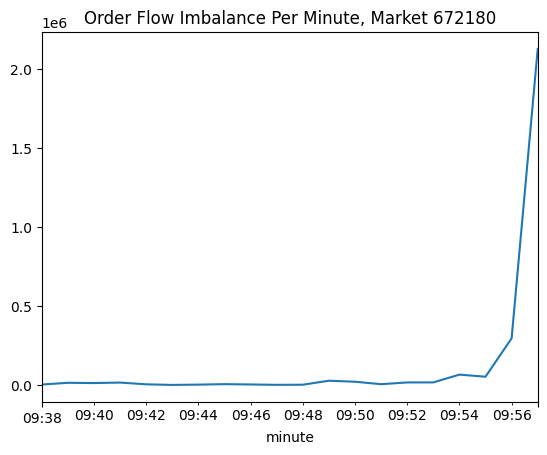

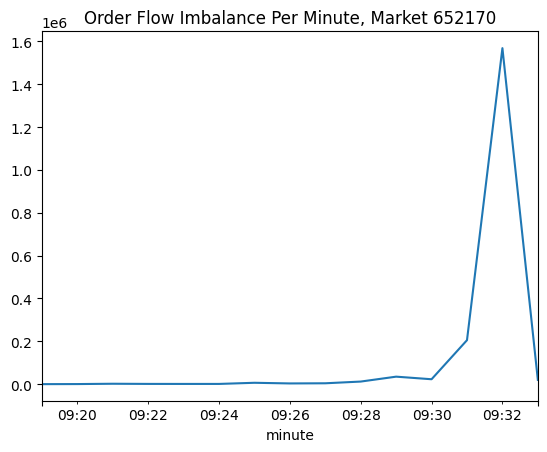

In [77]:
for m in top_markets:
    m_df = df[df["market_id"] == m]
    m_imbalance = m_df.groupby("minute")["signed_volume"].sum().sort_index()

    plt.figure()
    m_imbalance.plot()
    plt.title(f"Order Flow Imbalance Per Minute, Market {m}")
    plt.show()

## 8 What Drove the Largest Spike

In [78]:
peak_minute = volume_per_minute.idxmax()

peak_breakdown = (
    df[df["minute"] == peak_minute]
      .groupby("market_id")["size"]
      .sum()
      .sort_values(ascending=False)
      .head(15)
)

peak_minute, peak_breakdown

(Timestamp('1970-01-21 10:10:00'),
 market_id
 566167    6.306660e+06
 566198    3.759016e+05
 566237    2.466460e+05
 558957    2.126385e+05
 566238    1.820665e+05
 566236    1.480821e+05
 566163    1.442872e+05
 566242    1.397395e+05
 566194    1.348422e+05
 558939    1.010059e+05
 566152    7.666923e+04
 566202    6.035921e+04
 566172    5.777347e+04
 566154    5.377381e+04
 566239    4.908032e+04
 Name: size, dtype: float64)

## 9 Participant Concentration

In [79]:
df["maker_address"].nunique(), df["taker_address"].nunique()

(53304, 54369)

In [80]:
maker_trades = df.groupby("maker_address").size().sort_values(ascending=False)
taker_trades = df.groupby("taker_address").size().sort_values(ascending=False)

maker_trades.describe(), taker_trades.describe()

(count     53304.000000
 mean         21.336635
 std        1453.470587
 min           1.000000
 25%           1.000000
 50%           2.000000
 75%           5.000000
 max      332565.000000
 dtype: float64,
 count     54369.000000
 mean         20.857823
 std        1990.599474
 min           1.000000
 25%           1.000000
 50%           2.000000
 75%           4.000000
 max      332565.000000
 dtype: float64)

In [81]:
maker_trades.head(10)

maker_address
                                              332565
0x204f72f35326db932158cba6adff0b9a1da95e14     23249
0x51373c6b56e4a38bf97c301efbff840fc8451556     13430
0x2005d16a84ceefa912d4e380cd32e7ff827875ea     13415
0x4231e98f3b1044c3b34bf19cb27b9441d157f63e     11321
0x212954857f5efc138748c33d032a93bf95974222      8497
0x6a5cfe36360363a009323432b566017308b0b3f2      7661
0x83b9f9e2d28ab875b9c9f73cdd5535c4c8926124      7574
0xe8dd7741ccb12350957ec71e9ee332e0d1e6ec86      7082
0x9e5c74c0bf46f0bf3fcd1064d17e6201c67fd8e6      6587
dtype: int64

In [82]:
taker_trades.head(10)

taker_address
                                              332565
0xc5d563a36ae78145c45a50134d48a1215220f80a    321104
0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e     30894
0x204f72f35326db932158cba6adff0b9a1da95e14     19034
0x83b9f9e2d28ab875b9c9f73cdd5535c4c8926124     11382
0x6a5cfe36360363a009323432b566017308b0b3f2      8286
0xead152b855effa6b5b5837f53b24c0756830c76a      6326
0xe8dd7741ccb12350957ec71e9ee332e0d1e6ec86      5831
0xe3726a1b9c6ba2f06585d1c9e01d00afaedaeb38      4854
0xde0463ea7f611b065e8ab06bbfbddad75e6dfa37      4357
dtype: int64

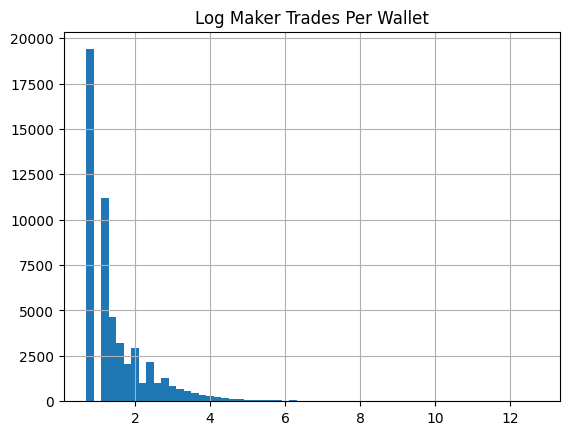

In [83]:
plt.figure()
np.log1p(maker_trades).hist(bins=60)
plt.title("Log Maker Trades Per Wallet")
plt.show()


In [84]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [85]:
# -----------------------------
# Dataset Identification
# -----------------------------
print("Dataset Name: Statsbomb/three_sixty.parquet")

Dataset Name: Statsbomb/three_sixty.parquet


In [86]:
# -----------------------------
# Data Retrieval
# -----------------------------
print("\n1. Data Retrieval")
print("1.1 Preprocessing")

PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")
DATA_PATH = PROJECT_ROOT / "data" / "Statsbomb" / "three_sixty.parquet"

df = pd.read_parquet(DATA_PATH)
print("Loaded dataset from:", DATA_PATH)
print("Shape:", df.shape)


1. Data Retrieval
1.1 Preprocessing
Loaded dataset from: C:\Users\bapna\Downloads\soccer-analytics-capstone-team14\data\Statsbomb\three_sixty.parquet
Shape: (15584040, 9)


In [87]:
# -----------------------------
# Dataset Overview
# -----------------------------
print("\n2. Dataset Overview")


2. Dataset Overview


In [88]:
# Integrity Checks
print("\n2.1 Data Integrity Checks")
print("Duplicate rows:", df.duplicated().sum())



2.1 Data Integrity Checks
Duplicate rows: 0


In [89]:
# Data Types & Ranges
print("\n2.2 Data Types & Ranges")
print(df.dtypes)


2.2 Data Types & Ranges
match_id          int32
id                int32
event_uuid       object
teammate           bool
actor              bool
keeper             bool
location_x      float32
location_y      float32
visible_area     object
dtype: object


In [90]:
# Missingness
print("\n2.3 Missingness & Completeness")
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(15))


2.3 Missingness & Completeness
match_id        0.0
id              0.0
event_uuid      0.0
teammate        0.0
actor           0.0
keeper          0.0
location_x      0.0
location_y      0.0
visible_area    0.0
dtype: float64


In [91]:
# Descriptive Statistics
print("\n2.4 Descriptive Statistics")
print(df.describe())


2.4 Descriptive Statistics
           match_id            id    location_x    location_y
count  1.558404e+07  1.558404e+07  1.558404e+07  1.558404e+07
mean   3.883339e+06  7.792020e+06  6.414864e+01  4.001791e+01
std    5.871480e+04  4.498725e+06  2.788267e+01  1.838046e+01
min    3.788741e+06  1.000000e+00 -8.284931e+00 -3.600099e+01
25%    3.857257e+06  3.896011e+06  4.353713e+01  2.684213e+01
50%    3.893809e+06  7.792020e+06  6.579242e+01  4.002510e+01
75%    3.930160e+06  1.168803e+07  8.630824e+01  5.318645e+01
max    4.020846e+06  1.558404e+07  1.294228e+02  1.175316e+02



2.5 Exploratory Visualization


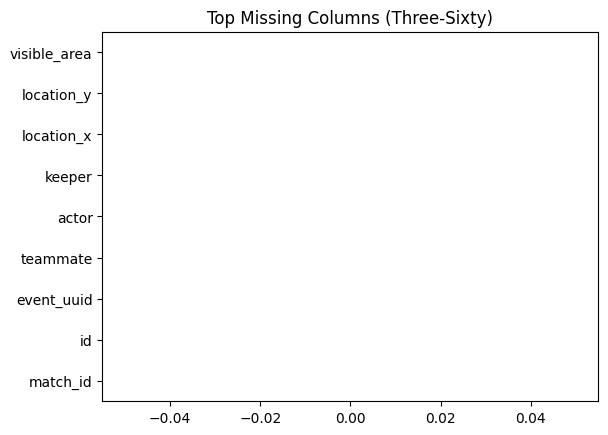

In [93]:
# Exploratory Visualization
print("\n2.5 Exploratory Visualization")
missing.head(10).plot.barh(title="Top Missing Columns (Three-Sixty)")
plt.show()

Dataset Name: Statsbomb/reference.parquet

1. Data Retrieval
1.1 Preprocessing
Loaded dataset from: C:\Users\bapna\Downloads\soccer-analytics-capstone-team14\data\Statsbomb\reference.parquet
Shape: (9566, 4)

1.2 Assumptions & Limitations
- This dataset contains reference and lookup tables.
- Some entities may not appear in the current match subset.
- No joins are performed in this exploratory analysis.

2. Dataset Overview

2.1 Data Integrity Checks
Duplicate rows: 0

2.2 Data Types & Ranges
table_name    object
id             int32
name          object
extra_info    object
dtype: object

2.3 Missingness & Completeness
extra_info    0.967384
table_name    0.000000
id            0.000000
name          0.000000
dtype: float64

2.4 Descriptive Statistics
       table_name             id   name extra_info
count        9566    9566.000000   9566        312
unique          6            NaN   9488          2
top        player            NaN  Wales       male
freq         9043            NaN 

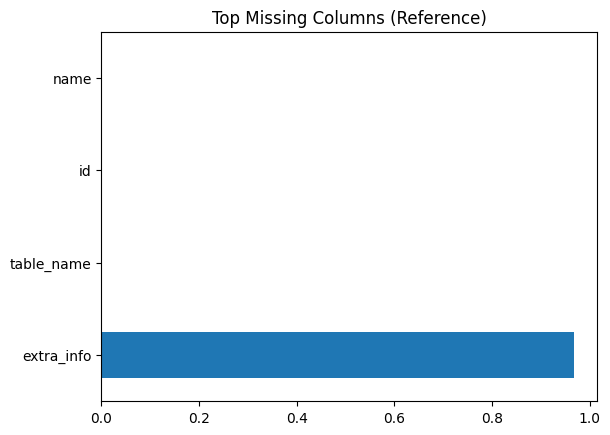

In [94]:
print("Dataset Name: Statsbomb/reference.parquet")

print("\n1. Data Retrieval")
print("1.1 Preprocessing")

PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")
DATA_PATH = PROJECT_ROOT / "data" / "Statsbomb" / "reference.parquet"

df = pd.read_parquet(DATA_PATH)
print("Loaded dataset from:", DATA_PATH)
print("Shape:", df.shape)

print("\n1.2 Assumptions & Limitations")
print("- This dataset contains reference and lookup tables.")
print("- Some entities may not appear in the current match subset.")
print("- No joins are performed in this exploratory analysis.")

print("\n2. Dataset Overview")

print("\n2.1 Data Integrity Checks")
print("Duplicate rows:", df.duplicated().sum())

print("\n2.2 Data Types & Ranges")
print(df.dtypes)

print("\n2.3 Missingness & Completeness")
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(15))

print("\n2.4 Descriptive Statistics")
print(df.describe(include='all'))

print("\n2.5 Exploratory Visualization")
missing.head(10).plot.barh(title="Top Missing Columns (Reference)")
plt.show()

Dataset Name: Polymarket/soccer_tokens.parquet

1. Data Retrieval
1.1 Preprocessing
Loaded dataset from: C:\Users\bapna\Downloads\soccer-analytics-capstone-team14\data\Polymarket\soccer_tokens.parquet
Shape: (17096, 3)

1.2 Assumptions & Limitations
- Token metadata may evolve over time.
- Not all tokens map cleanly to a single soccer match.
- Economic interpretation of tokens is out of scope for this EDA.

2. Dataset Overview

2.1 Data Integrity Checks
Duplicate rows: 0

2.2 Data Types & Ranges
market_id    object
token_id     object
outcome      object
dtype: object

2.3 Missingness & Completeness
market_id    0.0
token_id     0.0
outcome      0.0
dtype: float64

2.4 Descriptive Statistics
       market_id                                           token_id outcome
count      17096                                              17096   17096
unique      8547                                              17096     415
top       239883  1138364249130259162713989662271788847052251760...    

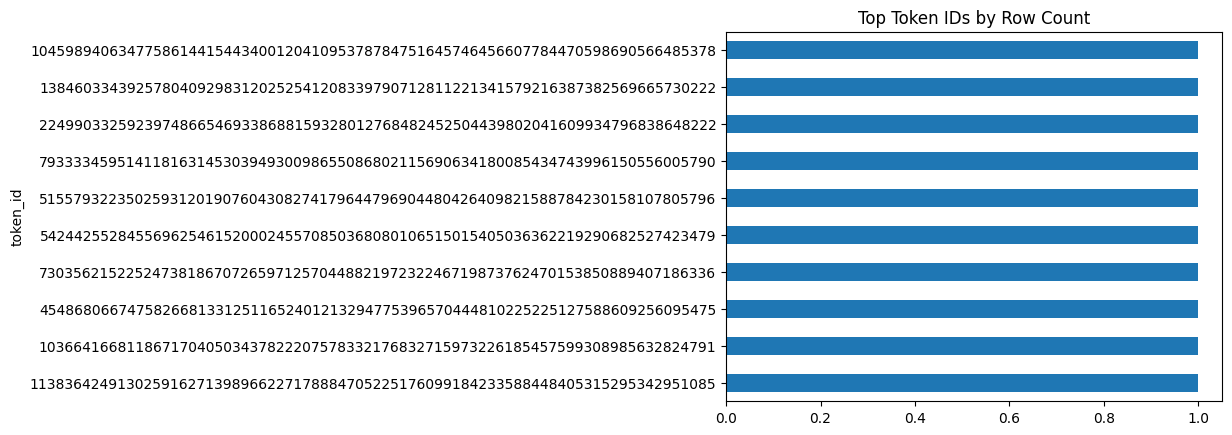

In [95]:
print("Dataset Name: Polymarket/soccer_tokens.parquet")

print("\n1. Data Retrieval")
print("1.1 Preprocessing")

PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")
DATA_PATH = PROJECT_ROOT / "data" / "Polymarket" / "soccer_tokens.parquet"

df = pd.read_parquet(DATA_PATH)
print("Loaded dataset from:", DATA_PATH)
print("Shape:", df.shape)

print("\n1.2 Assumptions & Limitations")
print("- Token metadata may evolve over time.")
print("- Not all tokens map cleanly to a single soccer match.")
print("- Economic interpretation of tokens is out of scope for this EDA.")

print("\n2. Dataset Overview")

print("\n2.1 Data Integrity Checks")
print("Duplicate rows:", df.duplicated().sum())

print("\n2.2 Data Types & Ranges")
print(df.dtypes)

print("\n2.3 Missingness & Completeness")
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(15))

print("\n2.4 Descriptive Statistics")
print(df.describe(include='all'))

print("\n2.5 Exploratory Visualization")
df["token_id"].value_counts().head(10).plot.barh(title="Top Token IDs by Row Count")
plt.show()

Dataset Name: Polymarket/soccer_summary.parquet

1. Data Retrieval
1.1 Preprocessing
Loaded dataset from: C:\Users\bapna\Downloads\soccer-analytics-capstone-team14\data\Polymarket\soccer_summary.parquet
Shape: (8549, 9)

1.2 Assumptions & Limitations
- Summary fields may be aggregated upstream.
- Coverage may vary across markets and time periods.
- This analysis validates structure, not market performance.

2. Dataset Overview

2.1 Data Integrity Checks
Duplicate rows: 0

2.2 Data Types & Ranges
market_id              object
question               object
slug                   object
volume                float64
active                   bool
token_count             int64
trade_count             int64
first_trade    datetime64[us]
last_trade     datetime64[us]
dtype: object

2.3 Missingness & Completeness
first_trade    0.620423
last_trade     0.620423
market_id      0.000000
question       0.000000
slug           0.000000
volume         0.000000
active         0.000000
token_count    

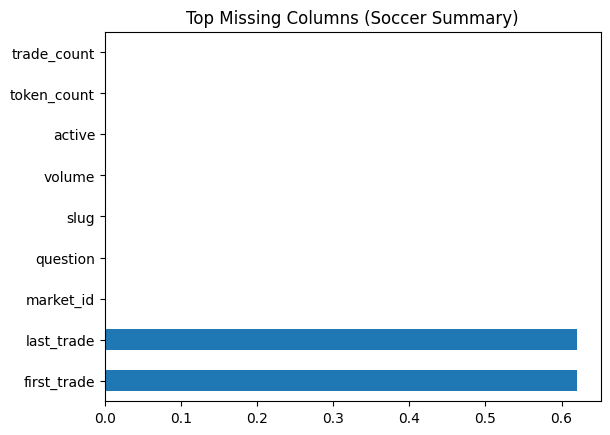

In [96]:
print("Dataset Name: Polymarket/soccer_summary.parquet")

print("\n1. Data Retrieval")
print("1.1 Preprocessing")

PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")
DATA_PATH = PROJECT_ROOT / "data" / "Polymarket" / "soccer_summary.parquet"

df = pd.read_parquet(DATA_PATH)
print("Loaded dataset from:", DATA_PATH)
print("Shape:", df.shape)

print("\n1.2 Assumptions & Limitations")
print("- Summary fields may be aggregated upstream.")
print("- Coverage may vary across markets and time periods.")
print("- This analysis validates structure, not market performance.")

print("\n2. Dataset Overview")

print("\n2.1 Data Integrity Checks")
print("Duplicate rows:", df.duplicated().sum())

print("\n2.2 Data Types & Ranges")
print(df.dtypes)

print("\n2.3 Missingness & Completeness")
missing = df.isna().mean().sort_values(ascending=False)
print(missing.head(15))

print("\n2.4 Descriptive Statistics")
print(df.describe(include='all'))

print("\n2.5 Exploratory Visualization")
missing.head(10).plot.barh(title="Top Missing Columns (Soccer Summary)")
plt.show()

In [97]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\bapna\Downloads\soccer-analytics-capstone-team14")

tokens_df = pd.read_parquet(
    PROJECT_ROOT / "data" / "Polymarket" / "soccer_tokens.parquet"
)

summary_df = pd.read_parquet(
    PROJECT_ROOT / "data" / "Polymarket" / "soccer_summary.parquet"
)

tokens_markets = set(tokens_df["market_id"])
summary_markets = set(summary_df["market_id"])

print("Markets in soccer_tokens:", len(tokens_markets))
print("Markets in soccer_summary:", len(summary_markets))
print("Overlap:", len(tokens_markets & summary_markets))

Markets in soccer_tokens: 8547
Markets in soccer_summary: 8549
Overlap: 8547


StatsBomb three_sixty data is internally consistent and joinable at the match and event level using match_id and event identifiers.

Polymarket soccer_tokens and soccer_summary datasets are directly joinable using market_id with clear one-to-many relationships.

There is no direct join key between StatsBomb and Polymarket datasets; any cross-source analysis will require an explicit mapping layer.

This limitation informs downstream pipeline design but does not affect dataset validity.

This section evaluates **join feasibility and relationships** across the four datasets analyzed in this project.

### Dataset 1: StatsBomb / three_sixty.parquet

* **Primary identifiers:** `match_id`, event-level identifiers
* **Join scope:** Internal to StatsBomb datasets only
* **Findings:**

  * The dataset is internally consistent and joinable at the event–match level using `match_id`.
  * No Polymarket identifiers (e.g., `market_id`) or betting-related metadata are present.
* **Conclusion:**

  * This dataset cannot be directly joined to any Polymarket dataset.
  * It can only be used in cross-source analyses after introducing an external mapping layer.

### Dataset 2: StatsBomb / reference.parquet

* **Primary identifiers:** StatsBomb reference IDs (teams, players, competitions)
* **Join scope:** Lookup/reference joins within StatsBomb data
* **Findings:**

  * The dataset functions as a reference table for StatsBomb entities.
  * It does not contain market identifiers or Polymarket-related fields.
* **Conclusion:**

  * This dataset is joinable only within the StatsBomb data ecosystem.
  * It cannot be directly joined to Polymarket datasets.

### Dataset 3: Polymarket / soccer_tokens.parquet

* **Primary identifier:** `market_id`
* **Join scope:** Polymarket market-level data
* **Findings:**

  * The dataset contains token-level records with complete `market_id` coverage.
  * No missing or duplicate join keys were identified.
* **Conclusion:**

  * This dataset is directly joinable to `soccer_summary.parquet` on `market_id`.

### Dataset 4: Polymarket / soccer_summary.parquet

* **Primary identifier:** `market_id`
* **Join scope:** Market-level summary data
* **Findings:**

  * The dataset contains one row per market.
  * All markets referenced in `soccer_tokens` appear in this dataset.
  * Two additional markets appear in `soccer_summary` that have no corresponding token records.
* **Conclusion:**

  * A left join from `soccer_tokens` to `soccer_summary` on `market_id` is safe and preserves all token records.
  * These two additional markets likely represent inactive or token-less markets.

### Summary

* The **two Polymarket datasets** (`soccer_tokens` and `soccer_summary`) are **cleanly and directly joinable** on `market_id`.
* The **StatsBomb datasets** (`three_sixty` and `reference`) are **internally joinable** but **not directly joinable** to Polymarket datasets.
* Any analysis combining StatsBomb event data with Polymarket market data will require an **explicit mapping layer**, potentially based on team names, match metadata, and temporal alignment.
* StatsBomb event data can be used to predict future match outcomes when aggregated over past matches, whereas Polymarket datasets reflect market beliefs and should not be used as predictive inputs due to data leakage, but are instead used to analyze market reactions to on-field events.